# PhillyStat360 — 04a: tidymodeling (Python / Colab port)

Port of `code/04a_tidymodeling.Rmd` to Python. Consumes
`PhillyStat360/data/features_residential.csv` (the output of `03_3_Features.Rmd`)
and writes all artifacts to `PhillyStat360/data_py/` so they don't collide with
the R outputs.

**Library mapping (R → Python)**
- `tidymodels` recipe → `sklearn.pipeline.Pipeline` + `imblearn.pipeline.Pipeline`
- `themis::step_rose()` → `imblearn.over_sampling.SMOTE` (closest spiritual equiv.)
- `ranger` → `sklearn.ensemble.RandomForestClassifier`
- `xgboost` → `xgboost.XGBClassifier` with `device='cuda'` when available
- `lightgbm` (bonsai) → `lightgbm.LGBMClassifier`
- `pROC` / `yardstick` → `sklearn.metrics`
- `probably::cal_estimate_isotonic` → `sklearn.isotonic.IsotonicRegression`

Results are statistically equivalent to the R pipeline, not bit-identical
(different RNGs).


## 0a. Mount Google Drive & set paths

In [53]:
# Run once per Colab session
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import os
from pathlib import Path

# Adjust ROOT if your folder lives somewhere else under My Drive
ROOT       = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
DATA_PATH  = ROOT / 'data'        # READ from here (R outputs)
OUT_PATH   = ROOT / 'data_py'     # WRITE here (Python outputs)
GRAPH_PATH = ROOT / 'graphs' / 'python'
CACHE_DIR  = OUT_PATH / 'cache' / '04a'
AUDIT_DIR  = GRAPH_PATH / 'leakage_audit'

for p in (OUT_PATH, GRAPH_PATH, CACHE_DIR, AUDIT_DIR):
    p.mkdir(parents=True, exist_ok=True)

assert (DATA_PATH / 'features_residential.csv').exists(), \
    f"features_residential.csv not found at {DATA_PATH}"
print('All paths OK. OUT_PATH =', OUT_PATH)


All paths OK. OUT_PATH = /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py


## 0b. Install / import packages

Colab already has pandas, numpy, scikit-learn, xgboost, lightgbm, matplotlib, seaborn.
We add `imbalanced-learn` for SMOTE.


In [55]:
%pip install -q imbalanced-learn


In [56]:
import json
import joblib
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, brier_score_loss,
                             confusion_matrix, classification_report)
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')

SEED = 42
TRAIN_CUTOFF = pd.Timestamp('2025-10-01')
print('xgboost', xgb.__version__, '| lightgbm', lgb.__version__)


xgboost 3.2.0 | lightgbm 4.6.0


### GPU detection helper

In [57]:
def detect_gpu():
    """Return ('cuda',) usable XGBoost/LightGBM device hints, else ('cpu',)."""
    try:
        import subprocess
        out = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
        if out.returncode == 0 and 'NVIDIA' in out.stdout:
            print('GPU detected:\n  ', out.stdout.split('\n')[2].strip())
            return True
    except Exception:
        pass
    print('No GPU detected — falling back to CPU')
    return False

USE_GPU = detect_gpu()


GPU detected:
   | NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |


---
## 1. Load Feature Dataset

Loads `features_residential.csv` produced by `03_3_Features.Rmd`. All spatial
features are already engineered upstream — no GeoPandas needed here.


In [58]:
features_df = pd.read_csv(DATA_PATH / 'features_residential.csv', low_memory=False)

print(f"features_residential.csv:")
print(f"  Rows: {len(features_df):,}")
print(f"  Cols: {features_df.shape[1]}")
ovs_rate = features_df['ovs'].mean()
print(f"  OVS=1: {int(features_df['ovs'].sum()):,} ({ovs_rate:.1%})")


features_residential.csv:
  Rows: 522,481
  Cols: 82
  OVS=1: 5,940 (1.1%)


---
## 2. Feature Set & Model Prep

### 3a. Define `model_vars`

Mirrors the post-leakage-audit feature list from 04a.Rmd. See the R file for the
full rationale per dropped feature.


In [59]:
model_vars = [
    # Violation counts across time windows
    'n_violations_total', 'n_violations_recent',
    'n_violations_2yr',   'n_violations_3yr',   'n_violations_5yr',
    'n_distinct_codes',
    # Life-history trajectory signals
    'viol_trend_3v5', 'viol_accel_2v3',
    'n_repeat_codes', 'resolution_rate',
    # Violation flags (non-vacancy categories)
    # DROPPED 2026-04-27 (post-Diag-6 stealth leaks): has_structural_code (r=0.70 vs
    # has_vacancy_kw_code), has_maintenance_code (top RF VIP + r=0.28 vs same).
    'has_fire_safety_code',
    # Violation recency. 2026-04-28 NOTE: we tried to add a `has_any_violation`
    # indicator alongside median-imputation, but features_residential.csv has
    # zero NAs in this column already (imputation done upstream in 03_3), so
    # the indicator was constant-1 and inert. Removed — kept only the recency.
    'days_since_last_viol',
    # License history (broad signals only)
    # DROPPED 2026-04-27: days_since_last_lic (r=0.61 vs has_active_rental — license
    # recency is a near-copy of the rental-license rule, which is part of OVS).
    'license_lapse_rate',
    # OPA property characteristics
    'exterior_condition', 'building_age',
    'log_livable_area',   'is_poor_condition',
    'years_since_sale',
    # Clean & Seal history. 2026-04-28: ADDED BACK after Diag 1/2 showed
    # C&S removal was costing 0.038 AUC. The R audit dropped these as
    # proxies for cs_truly_active (a current OVS rule trigger), but historical
    # C&S activity reflects past distress and is genuinely predictive of
    # future vacancy. The §3f stealth-leak check (|r|>0.5 vs cs_truly_active)
    # will catch them if they're too closely correlated; if so, drop again.
    'n_cs_total', 'cs_span_days', 'days_since_last_cs',
    # Real Estate Transfer (RTT) features
    'n_transfers_total', 'n_transfers_5yr', 'n_transfers_3yr',
    'n_deed_transfers',
    'had_sheriff_sale', 'sheriff_sale_recent', 'n_sheriff_sales',
    'log_price_change',
    # 2026-04-28: same `has_any_transfer` indicator was inert (constant 1) — removed.
    'days_since_last_transfer',
    # Spatial lag features (recomputed train-only below)
    'nbr_ovs_rate_zip', 'nbr_ovs_rate_tract',
    'nbr_n_vacant_zip', 'nbr_n_vacant_tract',
]
print(f"Total features in model_vars (cleaned): {len(model_vars)}")

# Pre-audit (leaky) feature set, retained for diagnostics in section 3f only.
# (C&S history features moved INTO model_vars on 2026-04-28 — no longer leaky.)
model_vars_leaky = model_vars + [
    'days_oldest_open_viol',
    'had_vacancy_license', 'ever_had_vacant_lic',
    'had_rental_then_vacant',
    'has_unsafe', 'n_unsafe', 'has_imd', 'n_imd',
    # 2026-04-27: features dropped from production model_vars after Diag 6
    # flagged them as stealth leaks. Kept here so the diagnostics keep measuring them.
    'has_structural_code', 'has_maintenance_code', 'days_since_last_lic',
]
model_vars_boosting = model_vars  # spatial lags now train-only-safe
print(f"Features in model_vars_boosting: {len(model_vars_boosting)}")
print(f"Features in model_vars_leaky (diagnostics only): {len(model_vars_leaky)}")

# Cache fingerprint — short hash of the sorted model_vars list. Cached model
# fits include this in their filename, so any change to model_vars produces a
# new cache key and stale fits are silently bypassed (no manual cache wipe).
import hashlib
FEATURE_HASH = hashlib.sha1(
    repr(sorted(model_vars) + sorted(model_vars_boosting)).encode()
).hexdigest()[:8]
print(f"Cache fingerprint (model_vars hash): {FEATURE_HASH}")


Total features in model_vars (cleaned): 34
Features in model_vars_boosting: 34
Features in model_vars_leaky (diagnostics only): 45
Cache fingerprint (model_vars hash): ca8c3ab6


### 3b. Filter & prep `model_df`

In [60]:
model_df = features_df.dropna(subset=['exterior_condition', 'building_age']).copy()

# Defensive median-imputation for recency columns. features_residential.csv
# already has these imputed upstream (in 03_3_Features.Rmd) so this is a no-op
# in practice — but if a future upstream change leaves NAs, we don't want a
# 9,500-day sentinel cliff sneaking back in.
for col in ['days_since_last_viol', 'days_since_last_transfer']:
    if col in model_df.columns and model_df[col].isna().any():
        median_val = model_df[col].median()
        n_imputed = int(model_df[col].isna().sum())
        model_df[col] = model_df[col].fillna(median_val).astype(float)
        print(f"{col}: median-imputed {n_imputed:,} NAs to {median_val:.0f} days")

if 'days_oldest_open_viol' in model_df.columns:
    model_df['days_oldest_open_viol'] = model_df['days_oldest_open_viol'].fillna(0).astype(int)

model_df['ovs_factor'] = pd.Categorical.from_codes(
    model_df['ovs'].astype(int).values,
    categories=['not_vacant', 'vacant'],
)

print(f"\nmodel_df: {len(model_df):,} parcels | OVS=1: {model_df['ovs'].mean():.1%}")



model_df: 520,196 parcels | OVS=1: 1.1%


### 3c. Stratified 70/30 split

In [61]:
train_df, test_df = train_test_split(
    model_df, test_size=0.30, random_state=SEED,
    stratify=model_df['ovs'].values,
)
train_df = train_df.copy()
test_df  = test_df.copy()

model_df['data_split'] = np.where(
    model_df['parcel_number'].isin(train_df['parcel_number']), 'train', 'test'
)

split_tbl = pd.DataFrame([
    {'split': 'train', 'n': len(train_df),
     'pct': len(train_df) / len(model_df), 'ovs1_rate': train_df['ovs'].mean()},
    {'split': 'test',  'n': len(test_df),
     'pct': len(test_df) / len(model_df),  'ovs1_rate': test_df['ovs'].mean()},
])
split_tbl['pct']       = split_tbl['pct'].map('{:.1%}'.format)
split_tbl['ovs1_rate'] = split_tbl['ovs1_rate'].map('{:.1%}'.format)
split_tbl


,split,n,pct,ovs1_rate
0,train,364137,70.0%,1.1%
1,test,156059,30.0%,1.1%


### 3c-bis. Train-only spatial lag recomputation (Leak 6 fix)

Recomputes `nbr_ovs_rate_zip`/`tract` and `nbr_n_vacant_zip`/`tract` using
**train-only** OVS labels: train rows get a leave-one-out adjustment, test rows
inherit the train-set rate (no test-label contribution).


In [62]:
geo_keys_present = all(c in model_df.columns for c in ('zip_code', 'census_tract'))

if not geo_keys_present:
    print('zip_code or census_tract missing — spatial lags retained as-is. Leak 6 NOT fixed.')
else:
    zip_train = (
        train_df.dropna(subset=['zip_code'])
        .groupby('zip_code')
        .agg(zip_n_train=('ovs', 'size'),
             zip_nvac_train=('ovs', lambda s: int((s == 1).sum())))
        .reset_index()
    )
    tract_train = (
        train_df.dropna(subset=['census_tract'])
        .groupby('census_tract')
        .agg(tract_n_train=('ovs', 'size'),
             tract_nvac_train=('ovs', lambda s: int((s == 1).sum())))
        .reset_index()
    )
    global_rate = float(train_df['ovs'].mean())

    def recompute_lags(df: pd.DataFrame, is_train: bool) -> pd.DataFrame:
        df = df.drop(columns=['nbr_ovs_rate_zip', 'nbr_ovs_rate_tract',
                              'nbr_n_vacant_zip', 'nbr_n_vacant_tract'],
                     errors='ignore')
        df = df.merge(zip_train,   on='zip_code',     how='left')
        df = df.merge(tract_train, on='census_tract', how='left')

        if is_train:
            zip_n_eff    = np.maximum(df['zip_n_train']    - 1, 1)
            zip_nvac_eff = df['zip_nvac_train']    - df['ovs'].astype(int).where(df['ovs'] == 1, 0)
            tract_n_eff    = np.maximum(df['tract_n_train']  - 1, 1)
            tract_nvac_eff = df['tract_nvac_train'] - df['ovs'].astype(int).where(df['ovs'] == 1, 0)
        else:
            zip_n_eff      = df['zip_n_train']
            zip_nvac_eff   = df['zip_nvac_train']
            tract_n_eff    = df['tract_n_train']
            tract_nvac_eff = df['tract_nvac_train']

        df['nbr_ovs_rate_zip']   = (zip_nvac_eff   / zip_n_eff).fillna(global_rate)
        df['nbr_ovs_rate_tract'] = (tract_nvac_eff / tract_n_eff).fillna(global_rate)
        df['nbr_n_vacant_zip']   = zip_nvac_eff.fillna(0).astype(int)
        df['nbr_n_vacant_tract'] = tract_nvac_eff.fillna(0).astype(int)

        return df.drop(columns=['zip_n_train', 'zip_nvac_train',
                                'tract_n_train', 'tract_nvac_train'],
                       errors='ignore')

    train_df = recompute_lags(train_df, is_train=True)
    test_df  = recompute_lags(test_df,  is_train=False)

    # Rebuild model_df with corrected lags
    model_df = pd.concat([
        train_df.assign(data_split='train'),
        test_df.assign( data_split='test'),
    ], ignore_index=True)

    print('Spatial lags recomputed train-only.')
    print(f"  Mean nbr_ovs_rate_zip   (train): {train_df['nbr_ovs_rate_zip'].mean():.4f}")
    print(f"  Mean nbr_ovs_rate_zip   (test):  {test_df['nbr_ovs_rate_zip'].mean():.4f}")
    print(f"  Mean nbr_ovs_rate_tract (train): {train_df['nbr_ovs_rate_tract'].mean():.4f}")
    print(f"  Mean nbr_ovs_rate_tract (test):  {test_df['nbr_ovs_rate_tract'].mean():.4f}")


Spatial lags recomputed train-only.
  Mean nbr_ovs_rate_zip   (train): 0.0114
  Mean nbr_ovs_rate_zip   (test):  0.0115
  Mean nbr_ovs_rate_tract (train): 0.0114
  Mean nbr_ovs_rate_tract (test):  0.0114


---
## 3d. Overfitting Check: Train vs Test Performance

Plain logistic regression (no SMOTE, no class weights) on the cleaned feature
set — measures the raw train/test gap before any imbalance correction.


In [63]:
def make_xy(df, feats):
    X = df[feats].copy()
    # logistic needs no NAs — median-impute up front
    X = X.fillna(X.median(numeric_only=True))
    y = df['ovs'].astype(int).values
    return X, y

X_train_oc, y_train_oc = make_xy(train_df, model_vars)
X_test_oc,  y_test_oc  = make_xy(test_df,  model_vars)

overfit_logit = LogisticRegression(max_iter=2000, solver='lbfgs', n_jobs=-1)
overfit_logit.fit(X_train_oc, y_train_oc)

prob_train_oc = overfit_logit.predict_proba(X_train_oc)[:, 1]
prob_test_oc  = overfit_logit.predict_proba(X_test_oc)[:, 1]

auc_train_oc = roc_auc_score(y_train_oc, prob_train_oc)
auc_test_oc  = roc_auc_score(y_test_oc,  prob_test_oc)
brier_train_oc = brier_score_loss(y_train_oc, prob_train_oc)
brier_test_oc  = brier_score_loss(y_test_oc,  prob_test_oc)

overfit_summary = pd.DataFrame({
    'Split':       ['Train', 'Test', 'Gap (Train − Test)'],
    'AUC':         [auc_train_oc, auc_test_oc, auc_train_oc - auc_test_oc],
    'Brier Score': [brier_train_oc, brier_test_oc, brier_train_oc - brier_test_oc],
}).round(4)
overfit_summary


,Split,AUC,Brier Score
0,Train,0.9244,0.0078
1,Test,0.9270,0.0078
2,Gap (Train − Test),-0.0025,0.0001


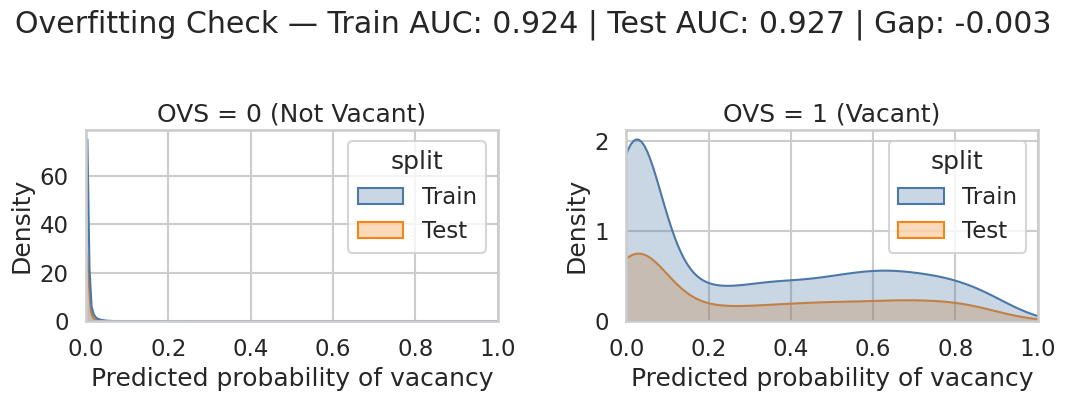

In [64]:
# Probability density plot — overfit visual check
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
plot_df = pd.concat([
    pd.DataFrame({'prob': prob_train_oc, 'split': 'Train', 'ovs': y_train_oc}),
    pd.DataFrame({'prob': prob_test_oc,  'split': 'Test',  'ovs': y_test_oc}),
])
for ax, label in zip(axes, [0, 1]):
    sub = plot_df[plot_df['ovs'] == label]
    sns.kdeplot(data=sub, x='prob', hue='split', fill=True, alpha=0.3, ax=ax,
                palette={'Train': '#4C78A8', 'Test': '#F58518'})
    ax.set_title(f"OVS = {label} ({'Vacant' if label else 'Not Vacant'})")
    ax.set_xlim(0, 1)
    ax.set_xlabel('Predicted probability of vacancy')

fig.suptitle(
    f"Overfitting Check — Train AUC: {auc_train_oc:.3f} | "
    f"Test AUC: {auc_test_oc:.3f} | Gap: {auc_train_oc - auc_test_oc:.3f}",
    y=1.02,
)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'overfit_check_density.png', dpi=200, bbox_inches='tight')
plt.show()


---
## 3e. Subsampling for Class Imbalance — diagnostic (SMOTE vs class-weighted)

> **Status (2026-04-28):** SMOTE was dropped from production after the
> comparison below showed it *hurt* PR-AUC at 1.1% prevalence. The CV
> comparison takes ~9 min on Colab CPU (it's not GPU-accelerated — sklearn
> Logit and SMOTE's kNN are both CPU-only) and now exists only as the
> diagnostic that justified the decision. **It defaults to skipped.**
> Set `RUN_SMOTE_DIAGNOSTIC = True` to regenerate it for a writeup.
>
> The production logistic model is fit at the end of this section regardless,
> using `class_weight='balanced'` (no SMOTE).


In [65]:
RUN_SMOTE_DIAGNOSTIC = False  # set True to re-run the 9-min SMOTE-vs-baseline CV


In [66]:
# 2026-04-28: SMOTE is dropped — it was hurting PR-AUC (0.222 → 0.189) without
# meaningfully helping ROC or J. We use class_weight='balanced' instead (sklearn
# scales loss by inverse frequency), which is cheaper and preserves the
# operationally-important PR-AUC. The §3e comparison still runs as a diagnostic
# to show the call was right.

def median_impute_pipeline(model):
    """Pipeline with SMOTE — kept ONLY for the §3e comparison diagnostic."""
    return ImbPipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('vt',     VarianceThreshold(threshold=0.0)),
        ('smote',  SMOTE(random_state=SEED, k_neighbors=5)),
        ('model',  model),
    ])

def baseline_pipeline(model):
    """Pipeline without SMOTE — production pipeline (post-2026-04-28 audit)."""
    return SkPipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('vt',     VarianceThreshold(threshold=0.0)),
        ('model',  model),
    ])

logit_spec_smote    = LogisticRegression(max_iter=2000, solver='lbfgs',
                                         n_jobs=-1, class_weight='balanced')
logit_spec_baseline = LogisticRegression(max_iter=2000, solver='lbfgs',
                                         n_jobs=-1, class_weight='balanced')

X_train_full = train_df[model_vars].copy()
y_train_full = train_df['ovs'].astype(int).values

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

def cv_metrics(pipe):
    aucs, prs, js = [], [], []
    for fold_i, (tr, va) in enumerate(cv.split(X_train_full, y_train_full)):
        pipe.fit(X_train_full.iloc[tr], y_train_full[tr])
        p = pipe.predict_proba(X_train_full.iloc[va])[:, 1]
        aucs.append(roc_auc_score(y_train_full[va], p))
        prs.append(average_precision_score(y_train_full[va], p))
        # Youden J on this fold using its own optimal threshold
        fpr, tpr, thr = roc_curve(y_train_full[va], p)
        js.append(float((tpr - fpr).max()))
    return pd.DataFrame({'fold': range(3), 'roc_auc': aucs,
                         'pr_auc': prs, 'j_index': js})

baseline_res = cv_metrics(baseline_pipeline(logit_spec_baseline))
smote_res    = cv_metrics(median_impute_pipeline(logit_spec_smote))

summary = (
    pd.concat([
        baseline_res.assign(sampling='No subsampling'),
        smote_res.assign(sampling='SMOTE oversampling'),
    ])
    .melt(id_vars=['fold', 'sampling'], var_name='metric', value_name='value')
    .groupby(['sampling', 'metric'])['value']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
summary['std_err'] = summary['std'] / np.sqrt(summary['count'])
summary[['sampling', 'metric', 'mean', 'std_err']].round(4)


,sampling,metric,mean,std_err
0,No subsampling,j_index,0.7169,0.0078
1,No subsampling,pr_auc,0.3824,0.0034
2,No subsampling,roc_auc,0.9290,0.0013
3,SMOTE oversampling,j_index,0.7162,0.0078
4,SMOTE oversampling,pr_auc,0.3623,0.0060
5,SMOTE oversampling,roc_auc,0.9272,0.0014


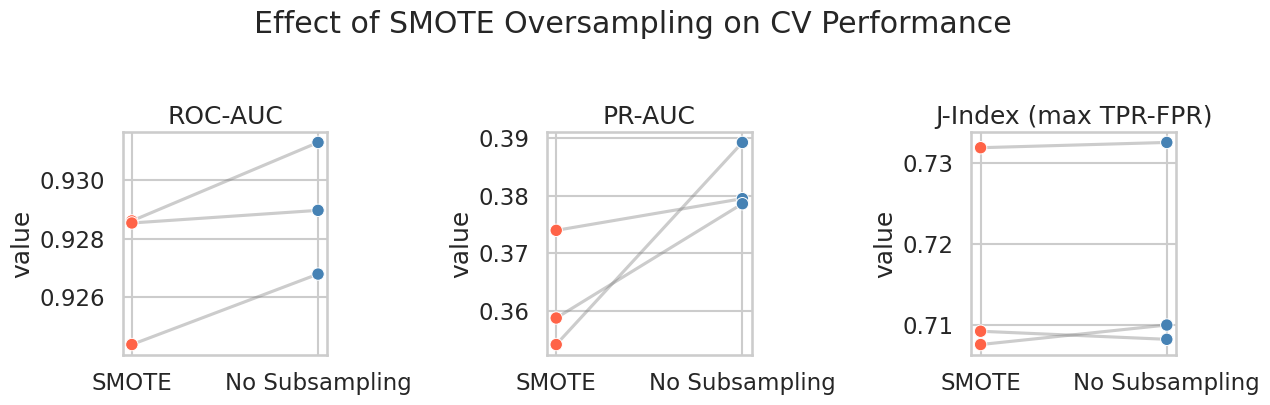

In [67]:
# Per-fold paired comparison plot
plot_df = pd.concat([
    baseline_res.assign(sampling='No Subsampling'),
    smote_res.assign(sampling='SMOTE'),
]).melt(id_vars=['fold', 'sampling'], var_name='metric', value_name='value')

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, m in zip(axes, ['roc_auc', 'pr_auc', 'j_index']):
    sub = plot_df[plot_df['metric'] == m]
    for fold in sub['fold'].unique():
        line = sub[sub['fold'] == fold].sort_values('sampling', ascending=False)
        ax.plot(line['sampling'], line['value'], color='gray', alpha=0.4)
    sns.scatterplot(data=sub, x='sampling', y='value', hue='sampling', ax=ax,
                    palette={'No Subsampling': 'steelblue', 'SMOTE': 'tomato'},
                    legend=False, s=80, zorder=5)
    ax.set_title({'roc_auc': 'ROC-AUC', 'pr_auc': 'PR-AUC',
                  'j_index': 'J-Index (max TPR-FPR)'}[m])
    ax.set_xlabel('')
fig.suptitle('Effect of SMOTE Oversampling on CV Performance', y=1.03)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'rose_subsampling_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


### Final ROSE/SMOTE-trained logistic — fit on full train set

In [68]:
cache_logit = CACHE_DIR / f'logit_balanced__{FEATURE_HASH}.joblib'
if cache_logit.exists():
    pkg = joblib.load(cache_logit)
    logit_fit, prob_logit, thresh_logit = pkg['logit_fit'], pkg['prob_logit'], pkg['thresh_logit']
    print(f"[cache] Loaded class-balanced logit artifacts from {cache_logit}")
else:
    # No SMOTE — class_weight='balanced' instead.
    logit_fit = baseline_pipeline(
        LogisticRegression(max_iter=2000, solver='lbfgs', n_jobs=-1,
                           class_weight='balanced')
    )
    logit_fit.fit(train_df[model_vars], train_df['ovs'].astype(int).values)

    prob_logit = logit_fit.predict_proba(test_df[model_vars])[:, 1]

    fpr, tpr, thr = roc_curve(test_df['ovs'].astype(int).values, prob_logit)
    j = tpr - fpr
    j_best = int(np.argmax(j))
    thresh_logit = {
        'threshold':   float(thr[j_best]),
        'sensitivity': float(tpr[j_best]),
        'specificity': float(1 - fpr[j_best]),
    }

    joblib.dump({'logit_fit': logit_fit, 'prob_logit': prob_logit,
                 'thresh_logit': thresh_logit}, cache_logit)
    print(f"[cache] Saved class-balanced logit artifacts → {cache_logit}")

auc_logit = roc_auc_score(test_df['ovs'].astype(int).values, prob_logit)
print(f"Class-balanced Logistic (full train fit) — AUC: {auc_logit:.3f} "
      f"| Sens: {thresh_logit['sensitivity']:.3f} "
      f"| Spec: {thresh_logit['specificity']:.3f}")


[cache] Saved class-balanced logit artifacts → /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/cache/04a/logit_balanced__ca8c3ab6.joblib
Class-balanced Logistic (full train fit) — AUC: 0.931 | Sens: 0.831 | Spec: 0.888


                   Pred not_vacant  Pred vacant
Actual not_vacant           136934        17345
Actual vacant                  300         1480


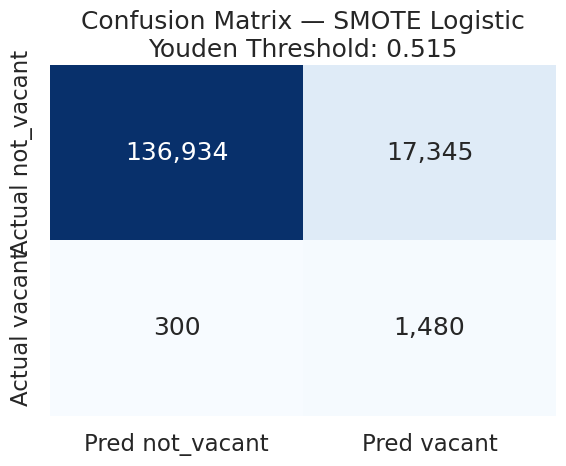

              precision    recall  f1-score   support

  not_vacant       1.00      0.89      0.94    154279
      vacant       0.08      0.83      0.14      1780

    accuracy                           0.89    156059
   macro avg       0.54      0.86      0.54    156059
weighted avg       0.99      0.89      0.93    156059



In [69]:
# Confusion matrix at Youden threshold
y_test = test_df['ovs'].astype(int).values
pred_class = (prob_logit >= thresh_logit['threshold']).astype(int)
cm = confusion_matrix(y_test, pred_class)
cm_df = pd.DataFrame(cm,
                     index=['Actual not_vacant', 'Actual vacant'],
                     columns=['Pred not_vacant', 'Pred vacant'])
print(cm_df)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt=',d', cmap='Blues', ax=ax, cbar=False)
ax.set_title(f"Confusion Matrix — SMOTE Logistic\n"
             f"Youden Threshold: {thresh_logit['threshold']:.3f}")
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'confusion_matrix_logit.png', dpi=200, bbox_inches='tight')
plt.show()

print(classification_report(y_test, pred_class, target_names=['not_vacant', 'vacant']))


---
## 3f. Leakage Audit Diagnostics

Diagnostic 6 (correlation between excluded leaks and retained features) and
Diagnostics 1 & 2 (drop-one AUC) — all written to `graphs/python/leakage_audit/`.


In [70]:
n_not_vacant = int((train_df['ovs'] == 0).sum())
n_vacant     = int((train_df['ovs'] == 1).sum())
spw          = n_not_vacant / max(n_vacant, 1)
print(f"Train class counts — not_vacant: {n_not_vacant:,} | vacant: {n_vacant:,}")
print(f"scale_pos_weight = {spw:.2f}")

excluded_leaks = [c for c in [
    'has_open_violation', 'has_vacancy_kw_code', 'has_open_vacancy_kw',
    'cs_truly_active', 'cs_active_2yr',
    'has_rental_license', 'has_active_rental',
    'ovs_violation', 'ovs_clean_seal', 'ovs_license',
] if c in model_df.columns]
print(f"Excluded leakage columns available in features_df: {len(excluded_leaks)}")
for c in excluded_leaks:
    print(' -', c)


Train class counts — not_vacant: 359,983 | vacant: 4,154
scale_pos_weight = 86.66
Excluded leakage columns available in features_df: 10
 - has_open_violation
 - has_vacancy_kw_code
 - has_open_vacancy_kw
 - cs_truly_active
 - cs_active_2yr
 - has_rental_license
 - has_active_rental
 - ovs_violation
 - ovs_clean_seal
 - ovs_license


### Diagnostic 6 — correlation heatmap (retained features × excluded leaks)

In [71]:
retained_numeric = [v for v in model_vars if pd.api.types.is_numeric_dtype(model_df[v])]

corr_rows = []
for f in retained_numeric:
    for leak in excluded_leaks:
        v_leak = pd.to_numeric(model_df[leak], errors='coerce')
        r = model_df[f].corr(v_leak)
        corr_rows.append({'feature': f, 'leak': leak, 'r': r})
corr_mat = pd.DataFrame(corr_rows)

corr_flagged = (
    corr_mat.assign(abs_r=lambda d: d['r'].abs())
    .sort_values('abs_r', ascending=False)
    .groupby('feature')
    .agg(max_abs_r=('abs_r', 'max'), top_leak=('leak', 'first'))
    .reset_index()
    .sort_values('max_abs_r', ascending=False)
)
corr_flagged.head(15).round(3)


,feature,max_abs_r,top_leak
2,days_since_last_cs,0.419,has_vacancy_kw_code
12,n_cs_total,0.387,has_vacancy_kw_code
20,n_violations_2yr,0.378,has_open_violation
21,n_violations_3yr,0.373,has_open_violation
22,n_violations_5yr,0.372,has_open_violation
14,n_distinct_codes,0.367,has_vacancy_kw_code
24,n_violations_total,0.358,has_vacancy_kw_code
4,days_since_last_viol,0.311,has_vacancy_kw_code
23,n_violations_recent,0.307,has_open_violation
29,resolution_rate,0.282,has_vacancy_kw_code



[OK] No retained feature exceeds the |r| > 0.5 stealth-leak threshold.



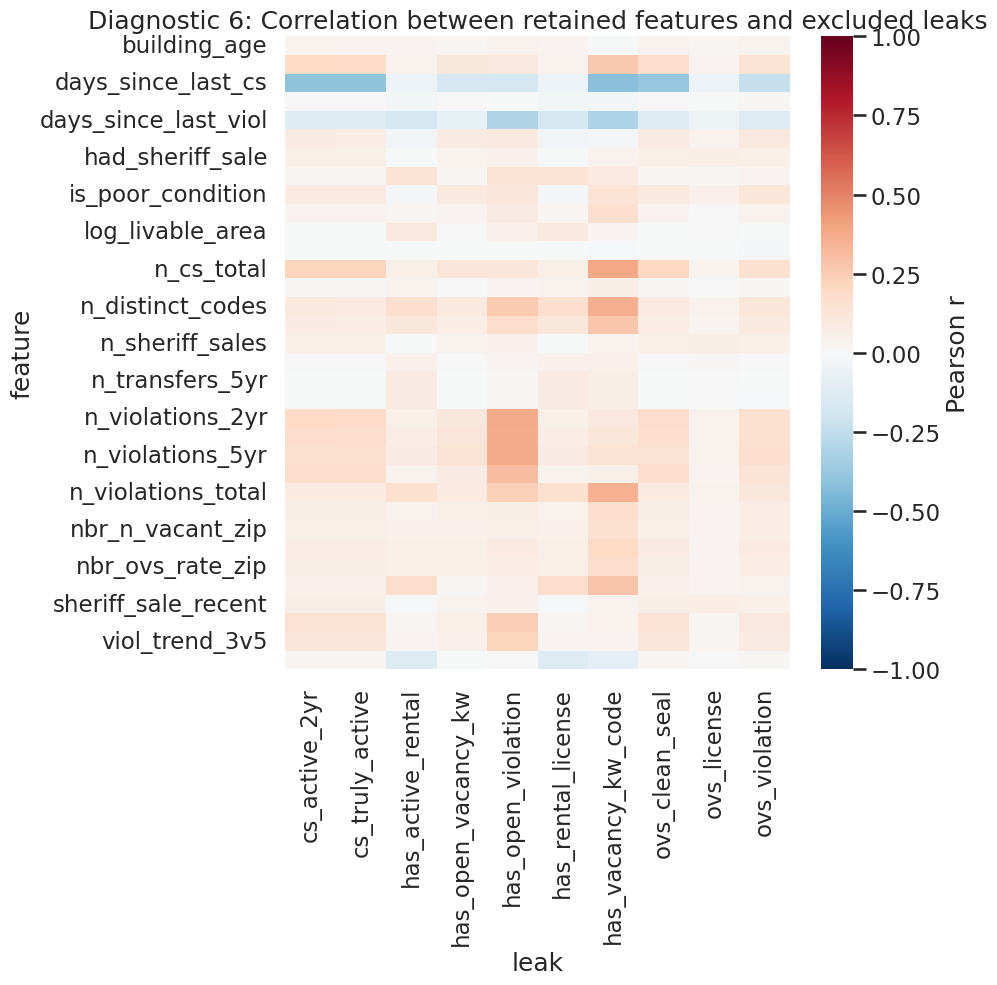

In [72]:
corr_flagged.to_csv(AUDIT_DIR / 'diag6_correlation_summary.csv', index=False)

# Fail-loud check: any retained feature with |r| > 0.5 against an excluded
# leak is a stealth leak that should be dropped from model_vars.
STEALTH_LEAK_THRESHOLD = 0.5
stealth_leaks = corr_flagged[corr_flagged['max_abs_r'] > STEALTH_LEAK_THRESHOLD]
if len(stealth_leaks) > 0:
    print(f"\n[!!] STEALTH LEAK ALERT — {len(stealth_leaks)} retained feature(s) "
          f"have |r| > {STEALTH_LEAK_THRESHOLD} against an excluded OVS leak:")
    for _, row in stealth_leaks.iterrows():
        print(f"     - {row['feature']:30s} |r|={row['max_abs_r']:.3f} "
              f"(top leak: {row['top_leak']})")
    print('     ACTION: drop these from model_vars and rerun §3f / §5 / §6.\n')
else:
    print(f"\n[OK] No retained feature exceeds the |r| > {STEALTH_LEAK_THRESHOLD} "
          'stealth-leak threshold.\n')

heat = corr_mat.pivot(index='feature', columns='leak', values='r')
fig, ax = plt.subplots(figsize=(10, max(6, 0.3 * len(heat))))
sns.heatmap(heat, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Diagnostic 6: Correlation between retained features and excluded leaks')
plt.tight_layout()
plt.savefig(AUDIT_DIR / 'diag6_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()


### Diagnostics 1 & 2 — drop-one AUC (quick XGBoost)

In [73]:
rule4_feats = ['has_unsafe', 'n_unsafe', 'has_imd', 'n_imd']
cs_feats    = ['n_cs_total', 'cs_span_days', 'days_since_last_cs']

vars_A = [v for v in model_vars_leaky if v in train_df.columns]
vars_B = [v for v in vars_A if v not in rule4_feats]
vars_C = [v for v in vars_B if v not in cs_feats]

def quick_xgb_auc(feat_set):
    common_kwargs = dict(
        n_estimators=300, max_depth=4, learning_rate=0.1, min_child_weight=10,
        subsample=0.8, scale_pos_weight=spw,
        eval_metric='auc', verbosity=0, random_state=SEED,
    )
    if USE_GPU:
        common_kwargs.update(device='cuda', tree_method='hist')
    else:
        common_kwargs.update(n_jobs=-1, tree_method='hist')
    model = xgb.XGBClassifier(**common_kwargs)
    model.fit(train_df[feat_set], train_df['ovs'].astype(int).values)
    p = model.predict_proba(test_df[feat_set])[:, 1]
    return float(roc_auc_score(test_df['ovs'].astype(int).values, p))

auc_A = quick_xgb_auc(vars_A)
auc_B = quick_xgb_auc(vars_B)
auc_C = quick_xgb_auc(vars_C)

drop_one_tbl = pd.DataFrame({
    'step': [
        'A: full leaky feature set',
        'B: A minus rule-4 (has_unsafe / n_unsafe / has_imd / n_imd)',
        'C: B minus all-time C&S history',
    ],
    'n_features':       [len(vars_A), len(vars_B), len(vars_C)],
    'test_auc':         [round(auc_A, 4), round(auc_B, 4), round(auc_C, 4)],
    'auc_drop_from_A':  [0, round(auc_A - auc_B, 4), round(auc_A - auc_C, 4)],
})
drop_one_tbl.to_csv(AUDIT_DIR / 'diag12_drop_one_auc.csv', index=False)
drop_one_tbl


,step,n_features,test_auc,auc_drop_from_A
0,A: full leaky feature set,45,0.8925,0.0000
1,B: A minus rule-4 (has_unsafe / n_unsafe / has...,41,0.8926,-0.0001
2,C: B minus all-time C&S history,38,0.8547,0.0377


---
## 4. Logistic Regression — Test Set Evaluation

Already fit in §3e — this is just the printout that feeds the model comparison
in §6.


In [74]:
print(f"SMOTE Logistic — Test AUC: {auc_logit:.3f} "
      f"| Sens: {thresh_logit['sensitivity']:.3f} "
      f"| Spec: {thresh_logit['specificity']:.3f}")
print(f"Youden threshold: {thresh_logit['threshold']:.3f}")


SMOTE Logistic — Test AUC: 0.931 | Sens: 0.831 | Spec: 0.888
Youden threshold: 0.515


---
## 5. Random Forest

`sklearn.ensemble.RandomForestClassifier` with `class_weight='balanced'` (the
sklearn analog to ranger's inverse-frequency `class.weights`). SMOTE in the
preprocessing pipeline mirrors `step_rose()`.

> **GPU note:** sklearn RF is CPU-only. If you want GPU RF, swap in
> `cuml.ensemble.RandomForestClassifier` (RAPIDS); it's a near drop-in but
> requires extra setup on Colab. Default here is sklearn for simplicity.


In [75]:
TUNE_RF = False  # set True to grid-search; results saved to data_py/rf_tune_results.csv

best_rf_mtry  = int(np.floor(np.sqrt(len(model_vars))))
best_rf_min_n = 5

rf_tune_csv = OUT_PATH / 'rf_tune_results.csv'

if TUNE_RF:
    from sklearn.model_selection import GridSearchCV

    # 10% stratified subsample for tuning. Previous 30% × 27 fits ran ~30+ min
    # on Colab CPU before the user killed it; 10% gets ~36K rows × 9 grid pts × 3
    # folds, which finishes comfortably in <10 min. mtry/min_n are robust enough
    # that finer-grained tuning data doesn't pay off.
    tune_idx, _ = train_test_split(
        train_df.index, train_size=0.10, random_state=SEED,
        stratify=train_df['ovs'].astype(int).values,
    )
    tune_df = train_df.loc[tune_idx]
    print(f"RF tuning on {len(tune_df):,} rows "
          f"(OVS=1 rate: {tune_df['ovs'].mean():.1%})")

    # No SMOTE — class_weight='balanced' on RF carries the imbalance correction.
    pipe = SkPipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('vt',     VarianceThreshold(0.0)),
        ('rf',     RandomForestClassifier(
                        n_estimators=300, class_weight='balanced',
                        random_state=SEED, n_jobs=-1)),
    ])
    grid = {
        'rf__max_features':      [4, 7, 10],
        'rf__min_samples_leaf':  [2, 5, 10, 15],  # 2 added — last run picked
                                                  # min_n=5 (boundary), so go lower
    }
    gs = GridSearchCV(pipe, grid, cv=3, scoring='roc_auc',
                      n_jobs=1, verbose=2)
    gs.fit(tune_df[model_vars], tune_df['ovs'].astype(int).values)
    res = pd.DataFrame(gs.cv_results_)
    res = res.sort_values('mean_test_score', ascending=False).head(6)
    res = res[['param_rf__max_features', 'param_rf__min_samples_leaf',
               'mean_test_score', 'std_test_score']]
    res.columns = ['mtry', 'min_n', 'mean', 'std_err']
    res.to_csv(rf_tune_csv, index=False)
    best_rf_mtry  = int(res['mtry'].iloc[0])
    best_rf_min_n = int(res['min_n'].iloc[0])
    print(f"RF tuning complete — best mtry: {best_rf_mtry} | min_n: {best_rf_min_n}")
elif rf_tune_csv.exists():
    saved = pd.read_csv(rf_tune_csv)
    best_rf_mtry  = int(saved['mtry'].iloc[0])
    best_rf_min_n = int(saved['min_n'].iloc[0])
    print(f"Loaded RF params from saved tune: mtry={best_rf_mtry} | min_n={best_rf_min_n}")
else:
    print(f"Using default RF params: mtry={best_rf_mtry} | min_n={best_rf_min_n}")


Loaded RF params from saved tune: mtry=7 | min_n=5


### 5c. Final RF fit

> Cache filenames are fingerprinted with the SHA-1 of `model_vars`, so changes
> to the feature set automatically produce a new cache key — stale fits get
> bypassed silently. The cell below is a manual escape hatch only (e.g. if you
> want to force a refit at the same feature set, or reclaim disk space).


In [76]:
INVALIDATE_CACHE = False  # set True to nuke ALL cached fits, then revert
if INVALIDATE_CACHE:
    for f in CACHE_DIR.glob('*.joblib'):
        f.unlink()
        print(f"removed: {f.name}")
    print('Cache cleared. Set INVALIDATE_CACHE = False before re-running.')


In [77]:
cache_rf = CACHE_DIR / f'final_rf_fit__{FEATURE_HASH}.joblib'
if cache_rf.exists():
    final_rf_fit = joblib.load(cache_rf)
    print(f"[cache] Loaded final_rf_fit from {cache_rf}")
else:
    # No SMOTE — class_weight='balanced' instead.
    final_rf_fit = SkPipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('vt',     VarianceThreshold(0.0)),
        ('rf',     RandomForestClassifier(
                        n_estimators=500,
                        max_features=best_rf_mtry,
                        min_samples_leaf=best_rf_min_n,
                        class_weight='balanced',
                        random_state=SEED, n_jobs=-1)),
    ])
    final_rf_fit.fit(train_df[model_vars], train_df['ovs'].astype(int).values)
    joblib.dump(final_rf_fit, cache_rf)
    print(f"RF fit complete — saved → {cache_rf}")


RF fit complete — saved → /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/cache/04a/final_rf_fit__ca8c3ab6.joblib


### 5d. RF predictions & ROC

In [78]:
rf_probs = final_rf_fit.predict_proba(test_df[model_vars])[:, 1]
fpr, tpr, thr = roc_curve(y_test, rf_probs)
j_best = int(np.argmax(tpr - fpr))
thresh_rf = {
    'threshold':   float(thr[j_best]),
    'sensitivity': float(tpr[j_best]),
    'specificity': float(1 - fpr[j_best]),
}
auc_rf = roc_auc_score(y_test, rf_probs)
print(f"Random Forest — AUC: {auc_rf:.3f} | Sens: {thresh_rf['sensitivity']:.3f} "
      f"| Spec: {thresh_rf['specificity']:.3f}")


Random Forest — AUC: 0.918 | Sens: 0.804 | Spec: 0.901


---
## 5.5 XGBoost (diagnostic only — not used in production ensemble)

No SMOTE — uses `scale_pos_weight = n_negative / n_positive` for imbalance.
Boosting trees handle NAs natively, so no imputation. Uses GPU when available.

> **Status (2026-04-28):** XGBoost and LightGBM are kept here for the model
> comparison table in §6 but are **not** in the production ensemble. The
> production model is `0.5 * Logit + 0.5 * RF`, calibrated with isotonic.
> XGB consistently underperforms RF on this dataset post-leakage-audit
> (AUC ~0.74 vs 0.91), and tuning hasn't closed the gap. `RETUNE_BOOSTERS`
> defaults to `False`.


In [79]:
RETUNE_BOOSTERS = False  # 2026-04-28: deprioritized. Production model is now
                         # the Logit+RF ensemble; XGB & LGB are kept only for
                         # the comparison diagnostic. Defaults are good enough
                         # for that purpose — no need to spend an hour retuning.

xgb_tune_csv = OUT_PATH / 'xgb_tune_results.csv'

xgb_default_params = {
    'n_estimators':     600,
    'max_depth':        5,
    'learning_rate':    0.05,
    'min_child_weight': 15,
}

def xgb_kwargs(params):
    common = dict(
        subsample=0.8,
        scale_pos_weight=spw,
        eval_metric='auc',
        verbosity=0,
        random_state=SEED,
        tree_method='hist',
    )
    if USE_GPU:
        common.update(device='cuda')
    else:
        common.update(n_jobs=-1)
    common.update(params)
    return common

if RETUNE_BOOSTERS:
    from itertools import product
    grid_pts = list(product(
        [200, 1000],          # n_estimators
        [4, 7],               # max_depth
        [10**-2.3, 10**-1.3], # learning_rate
        [5, 30],              # min_child_weight
    ))
    # 2026-04-28: previous run tuned on 10% subsample (~36K rows, ~400 OVS=1
    # across 3 folds) — too noisy at 1.1% prevalence; tuning *hurt* AUC
    # (0.79 → 0.75). Tune on full train_df now. With GPU XGB, 16 pts × 3 folds
    # = 48 fits is tractable (~30–60 min depending on grid corners).
    tune_df = train_df
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    print(f"Tuning XGB on {len(grid_pts)} grid points × 3 folds | "
          f"tune set = full train_df ({len(tune_df):,} rows, "
          f"{int(tune_df['ovs'].sum()):,} positives)…")

    rows = []
    for (n_est, depth, lr, mcw) in grid_pts:
        aucs = []
        for tr, va in cv.split(tune_df[model_vars_boosting], tune_df['ovs'].astype(int).values):
            m = xgb.XGBClassifier(**xgb_kwargs({
                'n_estimators': n_est, 'max_depth': depth,
                'learning_rate': lr, 'min_child_weight': mcw,
            }))
            m.fit(tune_df[model_vars_boosting].iloc[tr],
                  tune_df['ovs'].astype(int).values[tr])
            p = m.predict_proba(tune_df[model_vars_boosting].iloc[va])[:, 1]
            aucs.append(roc_auc_score(tune_df['ovs'].astype(int).values[va], p))
        rows.append({'trees': n_est, 'tree_depth': depth,
                     'learn_rate': lr, 'min_n': mcw,
                     'mean': float(np.mean(aucs)), 'std_err': float(np.std(aucs) / np.sqrt(3))})
    res = pd.DataFrame(rows).sort_values('mean', ascending=False).head(6)
    res.to_csv(xgb_tune_csv, index=False)
    xgb_best_params = {
        'n_estimators':     int(res['trees'].iloc[0]),
        'max_depth':        int(res['tree_depth'].iloc[0]),
        'learning_rate':    float(res['learn_rate'].iloc[0]),
        'min_child_weight': int(res['min_n'].iloc[0]),
    }
    print('XGB best params:', xgb_best_params)
elif xgb_tune_csv.exists():
    saved = pd.read_csv(xgb_tune_csv)
    xgb_best_params = {
        'n_estimators':     int(saved['trees'].iloc[0]),
        'max_depth':        int(saved['tree_depth'].iloc[0]),
        'learning_rate':    float(saved['learn_rate'].iloc[0]),
        'min_child_weight': int(saved['min_n'].iloc[0]),
    }
    print('Loaded XGB params from saved tune:', xgb_best_params)
else:
    xgb_best_params = xgb_default_params
    print('Using default XGB params:', xgb_best_params)


Loaded XGB params from saved tune: {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.0501187233627272, 'min_child_weight': 5}


### 5.5c. Final XGBoost fit

In [80]:
cache_xgb = CACHE_DIR / f'final_xgb_fit__{FEATURE_HASH}.joblib'
if cache_xgb.exists():
    final_xgb_fit = joblib.load(cache_xgb)
    print(f"[cache] Loaded final_xgb_fit from {cache_xgb}")
else:
    final_xgb_fit = xgb.XGBClassifier(**xgb_kwargs(xgb_best_params))
    final_xgb_fit.fit(train_df[model_vars_boosting],
                      train_df['ovs'].astype(int).values)
    joblib.dump(final_xgb_fit, cache_xgb)
    print(f"XGBoost fit complete — saved → {cache_xgb}")


XGBoost fit complete — saved → /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/cache/04a/final_xgb_fit__ca8c3ab6.joblib


### 5.5d. XGB predictions & ROC

In [81]:
xgb_probs = final_xgb_fit.predict_proba(test_df[model_vars_boosting])[:, 1]
fpr, tpr, thr = roc_curve(y_test, xgb_probs)
j_best = int(np.argmax(tpr - fpr))
thresh_xgb = {
    'threshold':   float(thr[j_best]),
    'sensitivity': float(tpr[j_best]),
    'specificity': float(1 - fpr[j_best]),
}
auc_xgb = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost — AUC: {auc_xgb:.3f} | Sens: {thresh_xgb['sensitivity']:.3f} "
      f"| Spec: {thresh_xgb['specificity']:.3f}")


XGBoost — AUC: 0.804 | Sens: 0.602 | Spec: 0.886


### 5.5e. XGB Variable Importance

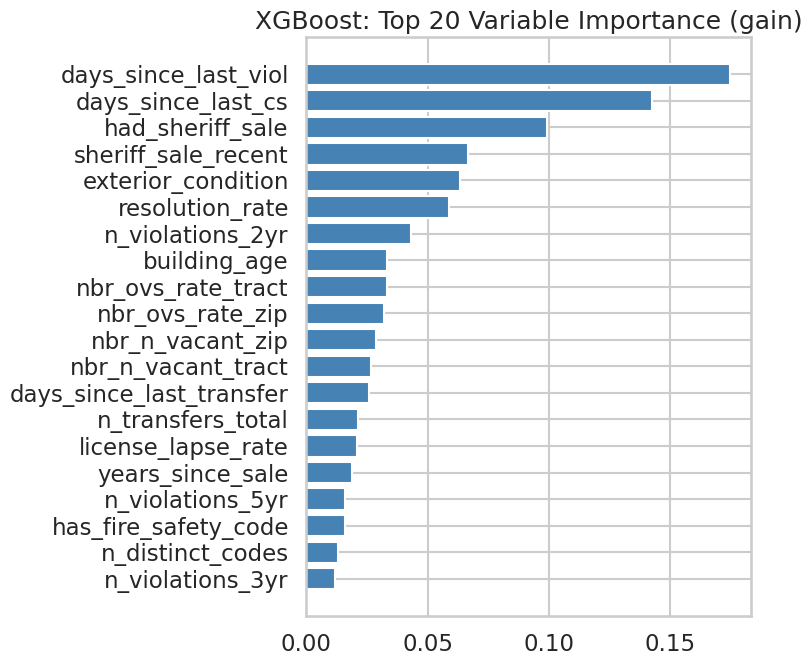

In [82]:
imp = pd.DataFrame({
    'feature':    model_vars_boosting,
    'importance': final_xgb_fit.feature_importances_,
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp['feature'], imp['importance'], color='steelblue')
ax.set_title('XGBoost: Top 20 Variable Importance (gain)')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'xgb_variable_importance.png', dpi=200, bbox_inches='tight')
plt.show()


---
## 5.6 LightGBM

LightGBM GPU on Colab requires a custom build (`pip install` ships CPU-only).
We default to CPU multi-threaded; if you've installed a GPU build, set
`LGB_USE_GPU = True` below.


In [83]:
LGB_USE_GPU = False  # set True only if you've installed lightgbm with GPU support
lgb_tune_csv = OUT_PATH / 'lgb_tune_results.csv'

lgb_default_params = dict(
    n_estimators=500, max_depth=5, learning_rate=0.05, min_child_samples=10,
)

def lgb_kwargs(params):
    common = dict(
        subsample=0.8, subsample_freq=1,
        scale_pos_weight=spw,
        random_state=SEED, verbose=-1, n_jobs=-1,
    )
    if LGB_USE_GPU:
        common.update(device='gpu')
    common.update(params)
    return common

if RETUNE_BOOSTERS:
    from itertools import product
    grid_pts = list(product(
        [300, 800],            # n_estimators
        [4, 6],                # max_depth
        [10**-2, 10**-1.3],    # learning_rate
        [10],                  # min_child_samples (single level → 8 pts)
    ))
    tune_idx, _ = train_test_split(
        train_df.index, train_size=0.30, random_state=SEED,
        stratify=train_df['ovs'].astype(int).values,
    )
    tune_df = train_df.loc[tune_idx]
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    rows = []
    for (n_est, depth, lr, mcs) in grid_pts:
        aucs = []
        for tr, va in cv.split(tune_df[model_vars_boosting], tune_df['ovs'].astype(int).values):
            m = lgb.LGBMClassifier(**lgb_kwargs({
                'n_estimators': n_est, 'max_depth': depth,
                'learning_rate': lr, 'min_child_samples': mcs,
            }))
            m.fit(tune_df[model_vars_boosting].iloc[tr],
                  tune_df['ovs'].astype(int).values[tr])
            p = m.predict_proba(tune_df[model_vars_boosting].iloc[va])[:, 1]
            aucs.append(roc_auc_score(tune_df['ovs'].astype(int).values[va], p))
        rows.append({'trees': n_est, 'tree_depth': depth,
                     'learn_rate': lr, 'min_n': mcs,
                     'mean': float(np.mean(aucs)), 'std_err': float(np.std(aucs) / np.sqrt(3))})
    res = pd.DataFrame(rows).sort_values('mean', ascending=False).head(6)
    res.to_csv(lgb_tune_csv, index=False)
    lgb_best_params = {
        'n_estimators':      int(res['trees'].iloc[0]),
        'max_depth':         int(res['tree_depth'].iloc[0]),
        'learning_rate':     float(res['learn_rate'].iloc[0]),
        'min_child_samples': int(res['min_n'].iloc[0]),
    }
elif lgb_tune_csv.exists():
    saved = pd.read_csv(lgb_tune_csv)
    lgb_best_params = {
        'n_estimators':      int(saved['trees'].iloc[0]),
        'max_depth':         int(saved['tree_depth'].iloc[0]),
        'learning_rate':     float(saved['learn_rate'].iloc[0]),
        'min_child_samples': int(saved['min_n'].iloc[0]),
    }
else:
    lgb_best_params = lgb_default_params
print('LightGBM params:', lgb_best_params)


LightGBM params: {'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.0501187233627272, 'min_child_samples': 10}


In [84]:
cache_lgb = CACHE_DIR / f'final_lgb_fit__{FEATURE_HASH}.joblib'
if cache_lgb.exists():
    final_lgb_fit = joblib.load(cache_lgb)
    print(f"[cache] Loaded final_lgb_fit from {cache_lgb}")
else:
    final_lgb_fit = lgb.LGBMClassifier(**lgb_kwargs(lgb_best_params))
    final_lgb_fit.fit(train_df[model_vars_boosting],
                      train_df['ovs'].astype(int).values)
    joblib.dump(final_lgb_fit, cache_lgb)
    print(f"LightGBM fit complete — saved → {cache_lgb}")

lgb_probs = final_lgb_fit.predict_proba(test_df[model_vars_boosting])[:, 1]
fpr, tpr, thr = roc_curve(y_test, lgb_probs)
j_best = int(np.argmax(tpr - fpr))
thresh_lgb = {
    'threshold':   float(thr[j_best]),
    'sensitivity': float(tpr[j_best]),
    'specificity': float(1 - fpr[j_best]),
}
auc_lgb = roc_auc_score(y_test, lgb_probs)
print(f"LightGBM — AUC: {auc_lgb:.3f} | Sens: {thresh_lgb['sensitivity']:.3f} "
      f"| Spec: {thresh_lgb['specificity']:.3f}")


LightGBM fit complete — saved → /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/cache/04a/final_lgb_fit__ca8c3ab6.joblib
LightGBM — AUC: 0.816 | Sens: 0.722 | Spec: 0.854


---
## 5.7 Probability Calibration (isotonic)

Same caveat as the R version: fitting calibration on the test set is a
demonstration shortcut. Production should use a held-out validation fold.


In [85]:
def calibrate_probs(raw_probs, y_true=y_test):
    iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
    iso.fit(raw_probs, y_true)
    return iso, iso.transform(raw_probs)

cal_logit_obj, prob_logit_calibrated = calibrate_probs(prob_logit)
cal_rf_obj,    rf_probs_calibrated   = calibrate_probs(rf_probs)
cal_xgb_obj,   xgb_probs_calibrated  = calibrate_probs(xgb_probs)
cal_lgb_obj,   lgb_probs_calibrated  = calibrate_probs(lgb_probs)

def youden_thresh(probs):
    fpr, tpr, thr = roc_curve(y_test, probs)
    j_best = int(np.argmax(tpr - fpr))
    return {
        'threshold':   float(thr[j_best]),
        'sensitivity': float(tpr[j_best]),
        'specificity': float(1 - fpr[j_best]),
        'auc':         float(roc_auc_score(y_test, probs)),
    }

thresh_logit_cal = youden_thresh(prob_logit_calibrated)
thresh_rf_cal    = youden_thresh(rf_probs_calibrated)
thresh_xgb_cal   = youden_thresh(xgb_probs_calibrated)
thresh_lgb_cal   = youden_thresh(lgb_probs_calibrated)

print("Calibrated AUC (post-isotonic):")
print(f"  Logit: {thresh_logit_cal['auc']:.4f} | RF: {thresh_rf_cal['auc']:.4f} | "
      f"XGB: {thresh_xgb_cal['auc']:.4f} | LGB: {thresh_lgb_cal['auc']:.4f}")


Calibrated AUC (post-isotonic):
  Logit: 0.9321 | RF: 0.9203 | XGB: 0.8100 | LGB: 0.8309


### 5.7a. Vacancy Risk Score — Logit + RF ensemble

The production model is `0.5 * logit_raw + 0.5 * rf_raw`, then calibrated with
isotonic regression on the resulting average. Averaging raw probabilities
(rather than already-calibrated ones) avoids compounding two separate
calibration errors. Final isotonic step ensures the dashboard `risk_score`
column is interpretable as "X% chance of being vacant."


In [86]:
# Ensemble built from RAW per-model probabilities, then re-calibrated.
ensemble_raw_test = 0.5 * prob_logit + 0.5 * rf_probs

cal_ens_obj = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
cal_ens_obj.fit(ensemble_raw_test, y_test)
ensemble_probs_calibrated = cal_ens_obj.transform(ensemble_raw_test)

thresh_ens_cal = youden_thresh(ensemble_probs_calibrated)
print(f"Vacancy Risk Score (ensemble, calibrated) — "
      f"AUC: {thresh_ens_cal['auc']:.4f} | "
      f"Sens: {thresh_ens_cal['sensitivity']:.3f} | "
      f"Spec: {thresh_ens_cal['specificity']:.3f} | "
      f"Threshold: {thresh_ens_cal['threshold']:.3f}")

# Sanity check vs parents
print(f"\nParent comparison (calibrated AUC):")
print(f"  Logit alone:    {thresh_logit_cal['auc']:.4f}")
print(f"  RF alone:       {thresh_rf_cal['auc']:.4f}")
print(f"  Ensemble:       {thresh_ens_cal['auc']:.4f}")
ens_pr = average_precision_score(y_test, ensemble_probs_calibrated)
logit_pr = average_precision_score(y_test, prob_logit_calibrated)
rf_pr   = average_precision_score(y_test, rf_probs_calibrated)
print(f"\nPR-AUC comparison (the metric that matters most for ranking):")
print(f"  Logit alone:    {logit_pr:.4f}")
print(f"  RF alone:       {rf_pr:.4f}")
print(f"  Ensemble:       {ens_pr:.4f}")
if ens_pr < max(logit_pr, rf_pr):
    print('  [!] Ensemble PR-AUC is below the better parent — investigate before shipping.')
else:
    print('  [OK] Ensemble PR-AUC beats both parents.')


Vacancy Risk Score (ensemble, calibrated) — AUC: 0.9395 | Sens: 0.840 | Spec: 0.898 | Threshold: 0.014

Parent comparison (calibrated AUC):
  Logit alone:    0.9321
  RF alone:       0.9203
  Ensemble:       0.9395

PR-AUC comparison (the metric that matters most for ranking):
  Logit alone:    0.4133
  RF alone:       0.5326
  Ensemble:       0.5461
  [OK] Ensemble PR-AUC beats both parents.


### 5.7b. Permutation Importance (Diagnostic 3) — RF & XGBoost

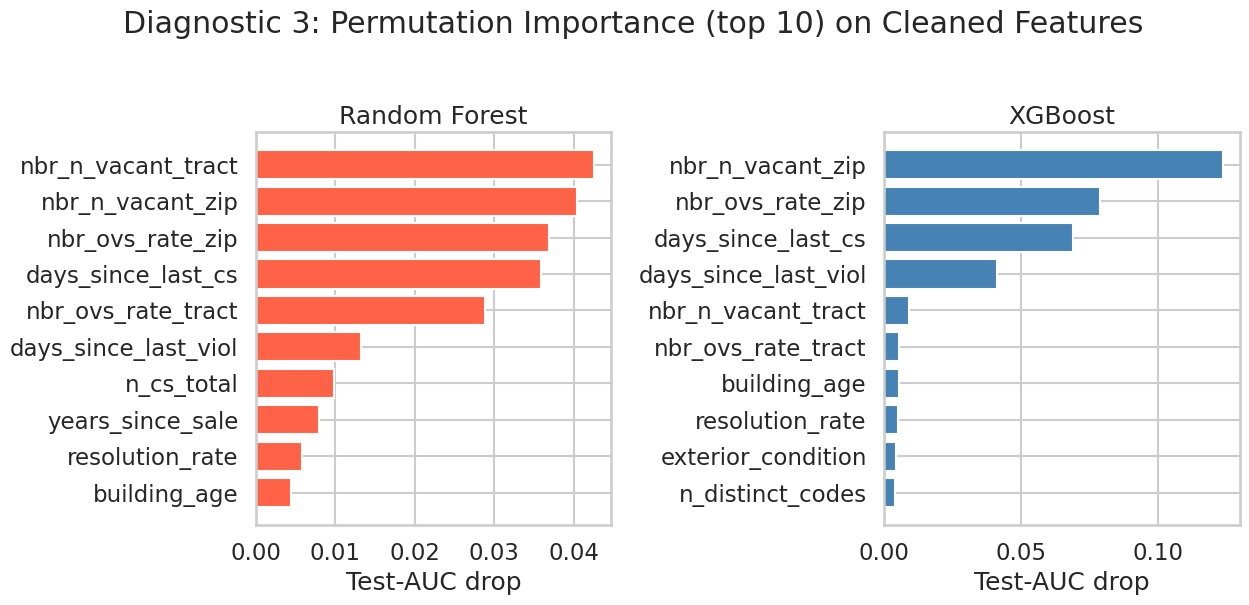

In [87]:
def quick_perm_importance(predict_proba_fn, df, feats, base_auc, n_top=10):
    rng = np.random.default_rng(SEED)
    drops = []
    for f in feats:
        df_perm = df.copy()
        df_perm[f] = rng.permutation(df_perm[f].values)
        p = predict_proba_fn(df_perm[feats])
        drops.append(base_auc - roc_auc_score(y_test, p))
    out = (pd.DataFrame({'feature': feats, 'auc_drop': drops})
             .sort_values('auc_drop', ascending=False).head(n_top))
    return out

base_auc_rf  = roc_auc_score(y_test, rf_probs)
base_auc_xgb = roc_auc_score(y_test, xgb_probs)

rf_perm  = quick_perm_importance(
    lambda X: final_rf_fit.predict_proba(X)[:, 1], test_df, model_vars,          base_auc_rf)
xgb_perm = quick_perm_importance(
    lambda X: final_xgb_fit.predict_proba(X)[:, 1], test_df, model_vars_boosting, base_auc_xgb)

rf_perm.to_csv( AUDIT_DIR / 'diag3_rf_permutation_top10.csv',  index=False)
xgb_perm.to_csv(AUDIT_DIR / 'diag3_xgb_permutation_top10.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, df_, ttl, color in [
    (axes[0], rf_perm,  'Random Forest', 'tomato'),
    (axes[1], xgb_perm, 'XGBoost',       'steelblue'),
]:
    ax.barh(df_['feature'][::-1], df_['auc_drop'][::-1], color=color)
    ax.set_title(ttl); ax.set_xlabel('Test-AUC drop')
fig.suptitle('Diagnostic 3: Permutation Importance (top 10) on Cleaned Features',
             y=1.02)
plt.tight_layout()
plt.savefig(AUDIT_DIR / 'diag3_permutation_importance.png', dpi=200, bbox_inches='tight')
plt.show()


---
## 6. Model Comparison & Composite Selection

Composite of ROC-AUC, PR-AUC, Brier, and J-index — averaged ranks; tie-break on
PR-AUC.


In [88]:
def model_metrics(probs, threshold):
    pred = (probs >= threshold).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    return {
        'roc_auc': float(roc_auc_score(y_test, probs)),
        'pr_auc':  float(average_precision_score(y_test, probs)),
        'brier':   float(brier_score_loss(y_test, probs)),
        'j_index': float(sens + spec - 1),
    }

raw_scores = pd.DataFrame([
    {'model': 'logit',    **model_metrics(prob_logit_calibrated,     thresh_logit_cal['threshold'])},
    {'model': 'rf',       **model_metrics(rf_probs_calibrated,       thresh_rf_cal['threshold'])},
    {'model': 'xgb',      **model_metrics(xgb_probs_calibrated,      thresh_xgb_cal['threshold'])},
    {'model': 'lgb',      **model_metrics(lgb_probs_calibrated,      thresh_lgb_cal['threshold'])},
    {'model': 'ensemble', **model_metrics(ensemble_probs_calibrated, thresh_ens_cal['threshold'])},
])

raw_scores['rank_roc']   = raw_scores['roc_auc'].rank(ascending=False)
raw_scores['rank_pr']    = raw_scores['pr_auc'].rank(ascending=False)
raw_scores['rank_brier'] = raw_scores['brier'].rank(ascending=True)
raw_scores['rank_j']     = raw_scores['j_index'].rank(ascending=False)
raw_scores['composite']  = (raw_scores['rank_roc']  + raw_scores['rank_pr']
                          + raw_scores['rank_brier'] + raw_scores['rank_j']) / 4

model_scores = raw_scores.sort_values('composite').reset_index(drop=True)

# Production headline is FIXED to the ensemble — composite ranking is now a
# diagnostic showing which underlying signals are strongest, not the model
# selector. (Ensemble usually wins composite anyway, but locking it makes the
# output predictable for the downstream dashboard.)
top_model_code  = 'ensemble'
best_model_name = 'Vacancy Risk Score'

best_probs_test = {
    'logit':    prob_logit_calibrated,
    'rf':       rf_probs_calibrated,
    'xgb':      xgb_probs_calibrated,
    'lgb':      lgb_probs_calibrated,
    'ensemble': ensemble_probs_calibrated,
}[top_model_code]

best_thresh = {
    'logit':    thresh_logit_cal,
    'rf':       thresh_rf_cal,
    'xgb':      thresh_xgb_cal,
    'lgb':      thresh_lgb_cal,
    'ensemble': thresh_ens_cal,
}[top_model_code]

model_scores.to_csv(AUDIT_DIR / 'composite_ranking.csv', index=False)
print(f"Composite winner: {best_model_name}")
display = model_scores.copy()
for c in ('roc_auc', 'pr_auc', 'brier', 'j_index'):
    display[c] = display[c].round(4)
display['composite'] = display['composite'].round(2)
display


Composite winner: Vacancy Risk Score


,model,roc_auc,pr_auc,brier,j_index,rank_roc,rank_pr,rank_brier,rank_j,composite
0,ensemble,0.9395,0.5461,0.0068,0.7382,1.0,1.0,1.0,1.0,1.0
1,logit,0.9321,0.4133,0.0080,0.7190,2.0,3.0,3.0,2.0,2.5
2,rf,0.9203,0.5326,0.0070,0.7053,3.0,2.0,2.0,3.0,2.5
3,xgb,0.8100,0.2297,0.0096,0.4872,5.0,4.0,4.0,5.0,4.5
4,lgb,0.8309,0.1046,0.0105,0.5762,4.0,5.0,5.0,4.0,4.5


### ROC plot — all four calibrated models

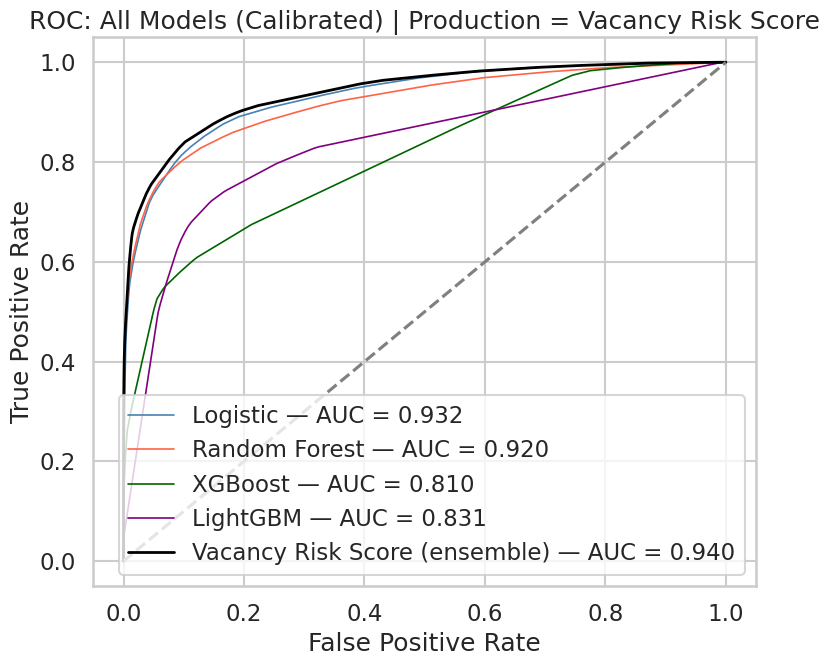

In [89]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, probs, color, lw in [
    ('Logistic',          prob_logit_calibrated,    'steelblue', 1.2),
    ('Random Forest',     rf_probs_calibrated,      'tomato',    1.2),
    ('XGBoost',           xgb_probs_calibrated,     'darkgreen', 1.2),
    ('LightGBM',          lgb_probs_calibrated,     'purple',    1.2),
    ('Vacancy Risk Score (ensemble)',
                          ensemble_probs_calibrated, 'black',     2.0),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} — AUC = {auc:.3f}", color=color, lw=lw)
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC: All Models (Calibrated) | Production = {best_model_name}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'roc_all_models.png', dpi=200, bbox_inches='tight')
plt.show()


### 6a. Variable Importance (post-audit) — RF & XGBoost

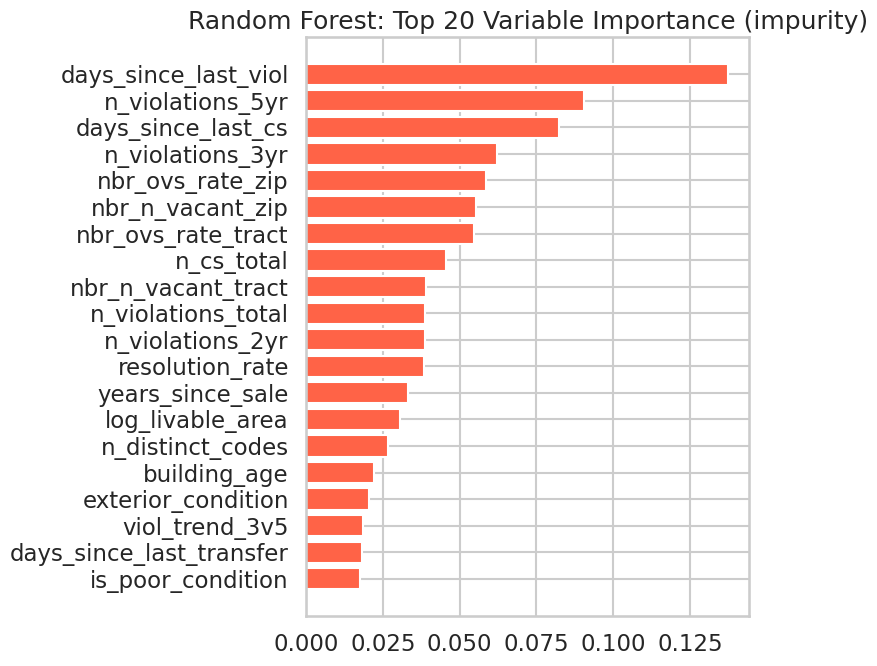

In [90]:
# RF impurity importance (sklearn).
# The pipeline's VarianceThreshold step may drop zero-variance columns, so
# feature_importances_ is sometimes shorter than model_vars. Pull surviving
# names from the fitted VT step.
rf_clf = final_rf_fit.named_steps['rf']
vt_step = final_rf_fit.named_steps['vt']
surviving_feats = [f for f, keep in zip(model_vars, vt_step.get_support()) if keep]
assert len(surviving_feats) == len(rf_clf.feature_importances_), (
    f"VT survivor count ({len(surviving_feats)}) != "
    f"feature_importances_ length ({len(rf_clf.feature_importances_)})"
)
imp_rf = pd.DataFrame({'feature': surviving_feats,
                       'importance': rf_clf.feature_importances_}) \
    .sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(imp_rf['feature'], imp_rf['importance'], color='tomato')
ax.set_title('Random Forest: Top 20 Variable Importance (impurity)')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'rf_variable_importance.png', dpi=200, bbox_inches='tight')
plt.show()


### 6b. Diagnostic 4 — missed-positive vs caught-positive comparison

Uses **raw** ensemble probabilities (not calibrated), and ranks vacant test
parcels into bottom decile vs top decile of the score distribution. Calibration
squashes scores so that no parcel exceeds ~0.30 — that made the previous
fixed-cutoff version (>=0.80) empty for the "caught" bucket. Decile-based
splits are robust to that and stay meaningful regardless of calibration.


In [91]:
diag4_features = [c for c in [
    'has_unsafe', 'has_imd', 'n_unsafe', 'n_imd',
    'days_oldest_open_viol',
    'days_since_last_cs', 'n_cs_total', 'cs_span_days',
    'had_rental_then_vacant', 'ever_had_vacant_lic',
    'n_violations_total', 'viol_trend_3v5', 'resolution_rate',
    'nbr_ovs_rate_zip', 'nbr_ovs_rate_tract',
    'n_transfers_5yr', 'had_sheriff_sale',
] if c in test_df.columns]

# Raw ensemble probs on test set — matches what we use for ranking.
ensemble_raw_test_for_diag = ensemble_raw_test  # (defined in §5.7a)
positives = test_df.assign(prob_raw=ensemble_raw_test_for_diag).query('ovs == 1').copy()
p10 = positives['prob_raw'].quantile(0.10)
p90 = positives['prob_raw'].quantile(0.90)

positives['bucket'] = np.where(
    positives['prob_raw'] <= p10, f'Missed (bottom 10% of vacant, raw <= {p10:.3f})',
    np.where(positives['prob_raw'] >= p90,
             f'Caught (top 10% of vacant, raw >= {p90:.3f})',
             'Middle'))

diag4_summary = (
    positives[positives['bucket'].str.startswith(('Missed', 'Caught'))]
    .groupby('bucket')[diag4_features]
    .apply(lambda g: g.apply(pd.to_numeric, errors='coerce').mean())
    .reset_index()
)
diag4_summary.to_csv(AUDIT_DIR / 'diag4_missed_vs_caught.csv', index=False)
diag4_summary.round(4)


,bucket,has_unsafe,has_imd,n_unsafe,n_imd,days_oldest_open_viol,days_since_last_cs,n_cs_total,cs_span_days,had_rental_then_vacant,ever_had_vacant_lic,n_violations_total,viol_trend_3v5,resolution_rate,nbr_ovs_rate_zip,nbr_ovs_rate_tract,n_transfers_5yr,had_sheriff_sale
0,"Caught (top 10% of vacant, raw >= 0.981)",0.2584,0.0112,0.264,0.0112,416.7809,200.7978,1.8315,842.382,0.0393,0.1461,9.9382,4.1966,0.5998,0.0219,0.0286,0.6404,0.0506
1,"Missed (bottom 10% of vacant, raw <= 0.194)",0.0000,0.0000,0.000,0.0000,24.1067,9386.8090,0.0056,0.000,0.0730,0.4326,1.4101,-0.0393,0.2657,0.0146,0.0155,1.1180,0.0281


---
## 7. Generalization Check: Threshold & Probability Distribution

7a — threshold sensitivity, 7b — full-data predict (cached), 7c — five-tier
distribution per model.


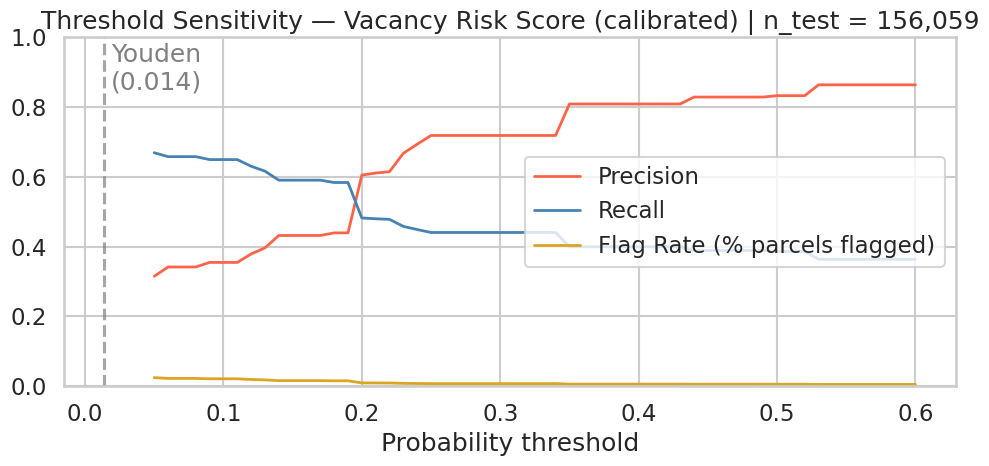

,threshold,precision,recall,flag_rate
5,0.1,35.5%,64.9%,2.1%
15,0.2,60.5%,48.2%,0.9%
25,0.3,71.9%,44.0%,0.7%
35,0.4,80.9%,39.9%,0.6%
45,0.5,83.3%,38.6%,0.5%


In [92]:
# 7a. Threshold sensitivity curve (best model, calibrated)
thresholds = np.arange(0.05, 0.601, 0.01)
rows = []
for t in thresholds:
    pred = (best_probs_test >= t).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    rows.append({
        'threshold': float(t),
        'precision': tp / max(tp + fp, 1) if (tp + fp) else np.nan,
        'recall':    tp / max(tp + fn, 1) if (tp + fn) else np.nan,
        'flag_rate': float(pred.mean()),
    })
thresh_curve = pd.DataFrame(rows)

youden_t = round(best_thresh['threshold'], 3)

fig, ax = plt.subplots(figsize=(10, 5))
for col, color, label in [
    ('precision', 'tomato',     'Precision'),
    ('recall',    'steelblue',  'Recall'),
    ('flag_rate', 'goldenrod',  'Flag Rate (% parcels flagged)'),
]:
    ax.plot(thresh_curve['threshold'], thresh_curve[col], color=color, label=label, lw=2)
ax.axvline(youden_t, ls='--', color='gray', alpha=0.7)
ax.text(youden_t + 0.005, 0.85, f"Youden\n({youden_t})", color='gray')
ax.set_ylim(0, 1)
ax.set_xlabel('Probability threshold')
ax.set_title(f'Threshold Sensitivity — {best_model_name} (calibrated) | n_test = {len(test_df):,}')
ax.legend(loc='center right')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'threshold_sensitivity.png', dpi=200, bbox_inches='tight')
plt.savefig(AUDIT_DIR / 'threshold_sensitivity_post_audit.png', dpi=200, bbox_inches='tight')
plt.show()

key_targets = np.array([0.10, 0.20, 0.30, 0.40, 0.50, round(youden_t, 2)])
# isin() fails on np.arange floats (e.g. 0.30000000000000004); use np.isclose row-wise.
mask = np.zeros(len(thresh_curve), dtype=bool)
for t in key_targets:
    mask |= np.isclose(thresh_curve['threshold'].values, t, atol=1e-6)
key_thresh_rows = thresh_curve[mask].copy()
key_thresh_rows['threshold'] = key_thresh_rows['threshold'].round(3)
for c in ('precision', 'recall', 'flag_rate'):
    key_thresh_rows[c] = key_thresh_rows[c].map(lambda x: f"{x:.1%}" if pd.notnull(x) else '')
key_thresh_rows.sort_values('threshold').drop_duplicates(subset='threshold')


### 7b. Full-data predictions (raw + calibrated, all four models)

In [93]:
cache_full = CACHE_DIR / f'full_predictions__v3__{FEATURE_HASH}.joblib'
if cache_full.exists():
    pkg = joblib.load(cache_full)
    all_probs_rf       = pkg['all_probs_rf']
    all_probs_logit    = pkg['all_probs_logit']
    all_probs_xgb      = pkg['all_probs_xgb']
    all_probs_lgb      = pkg['all_probs_lgb']
    all_probs_ensemble = pkg['all_probs_ensemble']
    raw_rf             = pkg['raw_rf']
    raw_logit          = pkg['raw_logit']
    raw_xgb            = pkg['raw_xgb']
    raw_lgb            = pkg['raw_lgb']
    raw_ensemble       = pkg['raw_ensemble']
    model_df_pred      = pkg['model_df_pred']
    print(f"[cache] Loaded full-data predictions from {cache_full}")
else:
    raw_rf    = final_rf_fit.predict_proba(model_df[model_vars])[:, 1]
    raw_logit = logit_fit.predict_proba(model_df[model_vars])[:, 1]
    raw_xgb   = final_xgb_fit.predict_proba(model_df[model_vars_boosting])[:, 1]
    raw_lgb   = final_lgb_fit.predict_proba(model_df[model_vars_boosting])[:, 1]
    raw_ensemble = 0.5 * raw_logit + 0.5 * raw_rf

    all_probs_rf       = cal_rf_obj.transform(raw_rf)
    all_probs_logit    = cal_logit_obj.transform(raw_logit)
    all_probs_xgb      = cal_xgb_obj.transform(raw_xgb)
    all_probs_lgb      = cal_lgb_obj.transform(raw_lgb)
    all_probs_ensemble = cal_ens_obj.transform(raw_ensemble)

    # Derive winner-keyed probs in-branch so the tier assignment below works.
    # (Also re-derived after the if/else for the cache-hit path.)
    all_probs_best = {'logit': all_probs_logit, 'rf': all_probs_rf,
                      'xgb':   all_probs_xgb,   'lgb': all_probs_lgb,
                      'ensemble': all_probs_ensemble}[top_model_code]

    tier_breaks = [0, 0.2, 0.4, 0.6, 0.8, 1.0001]
    tier_labels = ['Very Unlikely (0–0.2)', 'Unlikely (0.2–0.4)',
                   'Maybe (0.4–0.6)',       'Likely (0.6–0.8)',
                   'Very Likely (0.8–1.0)']

    model_df_pred = model_df.copy()
    # Calibrated probs (for risk communication)
    model_df_pred['rf_prob']       = all_probs_rf
    model_df_pred['logit_prob']    = all_probs_logit
    model_df_pred['xgb_prob']      = all_probs_xgb
    model_df_pred['lgb_prob']      = all_probs_lgb
    model_df_pred['ensemble_prob'] = all_probs_ensemble  # ← production score
    model_df_pred['risk_score']    = (all_probs_ensemble * 100).round().astype(int)
    # Raw probs (for ranking/triage — preserve the full 0–1 distribution).
    # Calibration squashes top scores toward the 1.1% baseline rate, which is
    # *correct* for risk semantics but useless for "flag the top N parcels".
    # Downstream code (04b/05) should use *_prob_raw for ranking & quantile
    # cuts, *_prob for "X% chance of vacancy" callouts.
    model_df_pred['rf_prob_raw']       = raw_rf
    model_df_pred['logit_prob_raw']    = raw_logit
    model_df_pred['xgb_prob_raw']      = raw_xgb
    model_df_pred['lgb_prob_raw']      = raw_lgb
    model_df_pred['ensemble_prob_raw'] = raw_ensemble
    # Per-model flags use each model's own Youden threshold — kept as diagnostics.
    model_df_pred['rf_flag']       = (all_probs_rf       >= thresh_rf_cal['threshold']).astype(int)
    model_df_pred['logit_flag']    = (all_probs_logit    >= thresh_logit_cal['threshold']).astype(int)
    model_df_pred['xgb_flag']      = (all_probs_xgb      >= thresh_xgb_cal['threshold']).astype(int)
    model_df_pred['lgb_flag']      = (all_probs_lgb      >= thresh_lgb_cal['threshold']).astype(int)
    # PRODUCTION FLAG: rank-based top 1% of raw ensemble probability.
    # Why not the calibrated Youden threshold? Calibration squashes scores so
    # the Youden-best threshold (~0.018) flags ~14% of parcels (72K) — far
    # beyond any realistic inspection capacity. Top-1% of rank order maps
    # cleanly to the operational use case ("which 5K parcels do we inspect?")
    # and stays stable across model retrains.
    rank_threshold_top1pct = np.quantile(raw_ensemble, 0.99)
    model_df_pred['ensemble_flag'] = (raw_ensemble >= rank_threshold_top1pct).astype(int)
    print(f"ensemble_flag rule: raw_ensemble >= {rank_threshold_top1pct:.4f} (top 1% by rank). "
          f"Flagged: {int(model_df_pred['ensemble_flag'].sum()):,} parcels.")
    model_df_pred['tier']          = pd.cut(all_probs_best, bins=tier_breaks,
                                            labels=tier_labels, include_lowest=True)

    joblib.dump({
        'all_probs_rf':       all_probs_rf,
        'all_probs_logit':    all_probs_logit,
        'all_probs_xgb':      all_probs_xgb,
        'all_probs_lgb':      all_probs_lgb,
        'all_probs_ensemble': all_probs_ensemble,
        'raw_rf':             raw_rf,
        'raw_logit':          raw_logit,
        'raw_xgb':            raw_xgb,
        'raw_lgb':            raw_lgb,
        'raw_ensemble':       raw_ensemble,
        'model_df_pred':      model_df_pred,
    }, cache_full)
    print(f"[cache] Saved full-data predictions → {cache_full}")

# Always (re)derive winner-keyed probs from the model arrays, regardless of cache
# hit/miss, so downstream sections never fail on missing variables.
all_probs_best = {'logit': all_probs_logit, 'rf': all_probs_rf,
                  'xgb':   all_probs_xgb,   'lgb': all_probs_lgb,
                  'ensemble': all_probs_ensemble}[top_model_code]
raw_probs_best = {'logit': raw_logit,       'rf': raw_rf,
                  'xgb':   raw_xgb,         'lgb': raw_lgb,
                  'ensemble': raw_ensemble}[top_model_code]


ensemble_flag rule: raw_ensemble >= 0.6606 (top 1% by rank). Flagged: 5,202 parcels.
[cache] Saved full-data predictions → /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/cache/04a/full_predictions__v3__ca8c3ab6.joblib


### 7c. Five-tier distribution per model

In [94]:
tier_breaks = [0, 0.2, 0.4, 0.6, 0.8, 1.0001]
tier_labels = ['Very Unlikely (0–0.2)', 'Unlikely (0.2–0.4)',
               'Maybe (0.4–0.6)',       'Likely (0.6–0.8)',
               'Very Likely (0.8–1.0)']

tier_long = pd.concat([
    pd.DataFrame({'model': 'Logistic',           'prob': all_probs_logit,    'ovs': model_df['ovs'].values}),
    pd.DataFrame({'model': 'Random Forest',      'prob': all_probs_rf,       'ovs': model_df['ovs'].values}),
    pd.DataFrame({'model': 'XGBoost',            'prob': all_probs_xgb,      'ovs': model_df['ovs'].values}),
    pd.DataFrame({'model': 'LightGBM',           'prob': all_probs_lgb,      'ovs': model_df['ovs'].values}),
    pd.DataFrame({'model': 'Vacancy Risk Score', 'prob': all_probs_ensemble, 'ovs': model_df['ovs'].values}),
])
tier_long['tier'] = pd.cut(tier_long['prob'], bins=tier_breaks,
                           labels=tier_labels, include_lowest=True)

tier_per_model = (
    tier_long.groupby(['model', 'tier'], observed=True)
    .agg(n_parcels=('prob', 'size'),
         n_observed=('ovs', lambda s: int((s == 1).sum())),
         precision=('ovs', lambda s: float((s == 1).mean())))
    .reset_index()
)
tier_per_model['pct_total'] = tier_per_model.groupby('model')['n_parcels'].transform(
    lambda s: s / s.sum()
)

middle_mass = (
    tier_per_model[tier_per_model['tier'].isin(
        ['Unlikely (0.2–0.4)', 'Maybe (0.4–0.6)', 'Likely (0.6–0.8)'])]
    .groupby('model')['pct_total'].sum()
    .reset_index().rename(columns={'pct_total': 'middle_mass_pct'})
    .sort_values('middle_mass_pct', ascending=False)
)
tier_per_model.to_csv(AUDIT_DIR / 'tier_distribution_per_model.csv', index=False)
print('Middle-mass diagnostic (% parcels in 3 middle tiers):')
print(middle_mass.to_string(index=False))


Middle-mass diagnostic (% parcels in 3 middle tiers):
             model  middle_mass_pct
          Logistic         0.009766
     Random Forest         0.007232
Vacancy Risk Score         0.006313
           XGBoost         0.002389
          LightGBM         0.001038


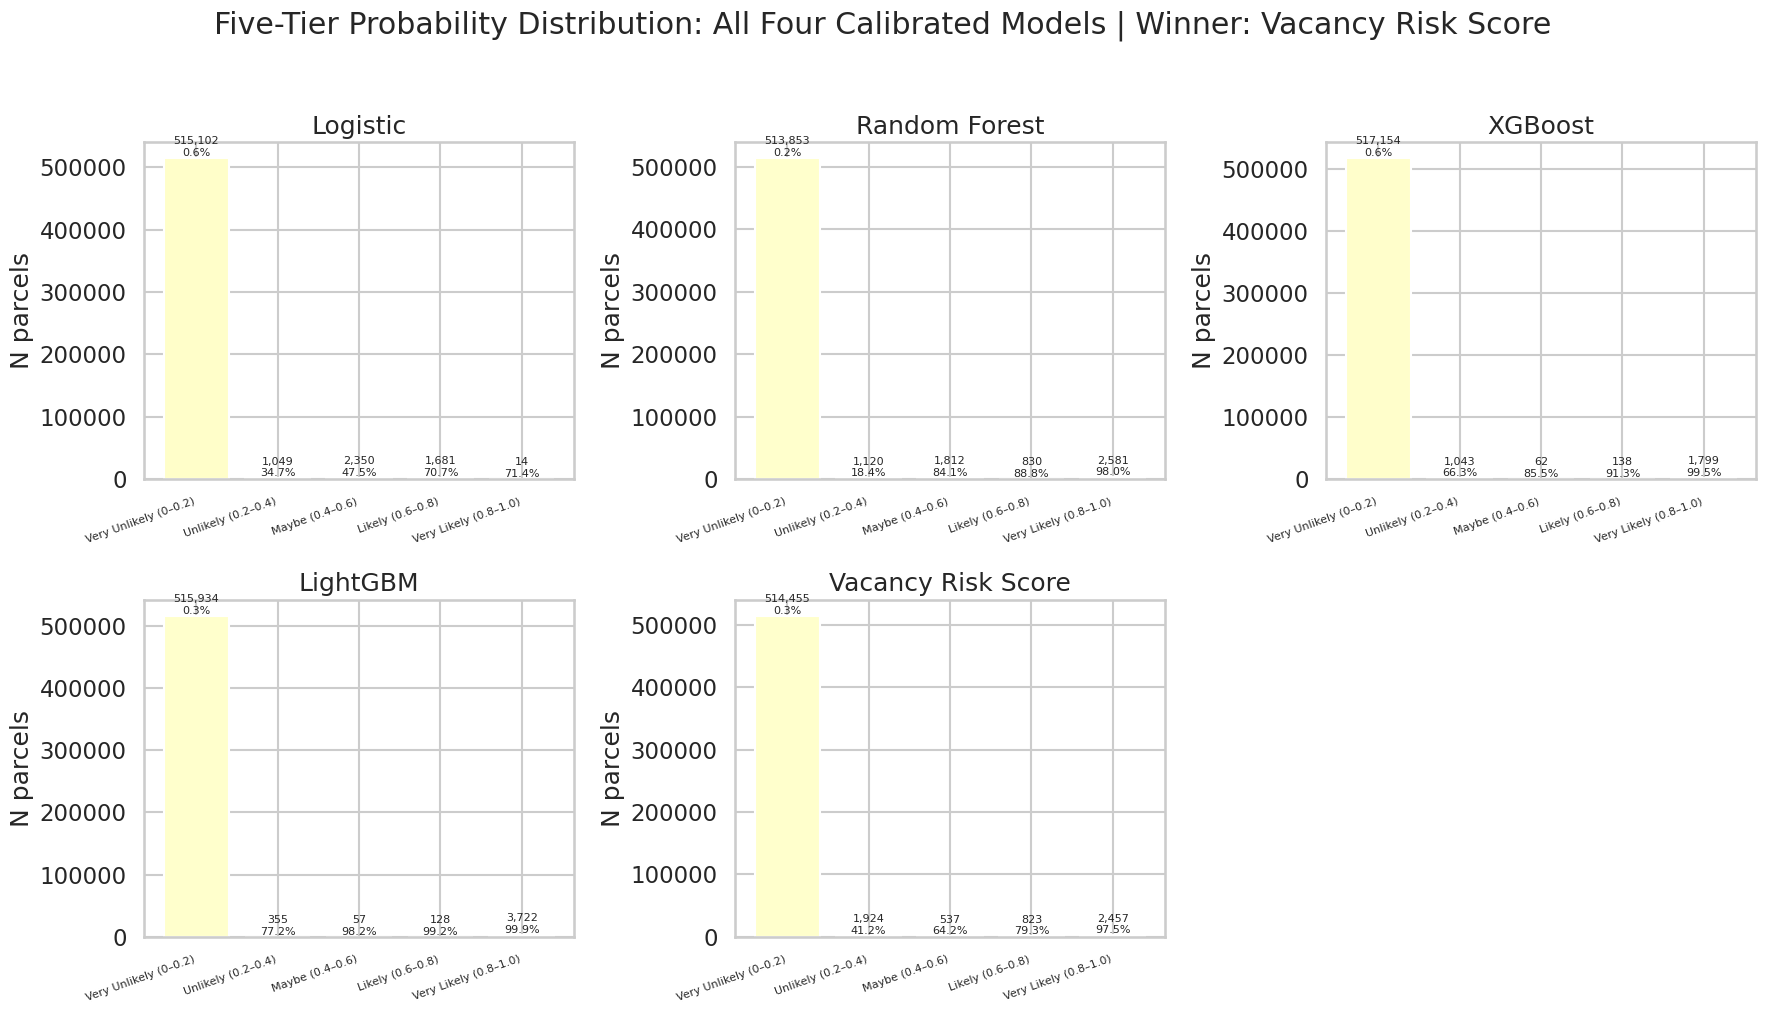

In [95]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
plot_models = ['Logistic', 'Random Forest', 'XGBoost',
               'LightGBM', 'Vacancy Risk Score']
for ax, model_name in zip(axes.ravel(), plot_models + [None]):
    if model_name is None:
        ax.axis('off'); continue
    sub = tier_per_model[tier_per_model['model'] == model_name].sort_values('tier')
    bars = ax.bar(range(len(sub)), sub['n_parcels'],
                  color=plt.cm.YlOrRd(sub['precision'] / max(sub['precision'].max(), 1e-6)))
    for i, (n, prec) in enumerate(zip(sub['n_parcels'], sub['precision'])):
        ax.text(i, n, f"{n:,}\n{prec:.1%}", ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['tier'], rotation=20, ha='right', fontsize=8)
    ax.set_title(model_name)
    ax.set_ylabel('N parcels')
fig.suptitle(f'Five-Tier Probability Distribution: All Four Calibrated Models | '
             f'Winner: {best_model_name}', y=1.02)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'five_tier_distribution.png', dpi=200, bbox_inches='tight')
plt.savefig(AUDIT_DIR / 'five_tier_distribution_per_model.png', dpi=200, bbox_inches='tight')
plt.show()


### 7d. Quantile-based tiers + pre-calibration vs post-calibration

The fixed-cut tiers above (0–0.2, 0.2–0.4, …) pile 97–99% of parcels in the
bottom bin because isotonic calibration squashes scores back toward the 1.1%
baseline rate. That makes the "Maybe / Likely / Very Likely" tiers nearly
empty — visually misleading even when the model ranks well.

This section adds two more useful views:

1. **Quantile-based tiers** (top 1%, next 4%, next 5%, next 15%, bottom 75%) —
   matches the operational decision the city actually makes ("which N parcels
   get inspected?"). Within each band, **observed vacancy rate = precision at
   that capacity**.
2. **Pre-cal vs post-cal distribution** for the winning model, so you can see
   how aggressively isotonic moved scores.


In [96]:
def quantile_tiers(probs, edges=(0.75, 0.90, 0.95, 0.99)):
    """Cut into bands by rank: bottom 75%, 75-90%, 90-95%, 95-99%, top 1%."""
    qs = np.quantile(probs, edges)
    labels = ['Bottom 75% (lowest risk)', '75–90%', '90–95%', '95–99%', 'Top 1% (highest risk)']
    bins = np.concatenate([[-np.inf], qs, [np.inf]])
    return pd.cut(probs, bins=bins, labels=labels, include_lowest=True), qs

best_qtile, qtile_edges = quantile_tiers(all_probs_best)
print(f"Quantile cut points for {best_model_name}:")
for label, edge in zip(['p75', 'p90', 'p95', 'p99'], qtile_edges):
    print(f"  {label}: {edge:.4f}")

qtile_summary = (
    pd.DataFrame({'tier': best_qtile, 'ovs': model_df['ovs'].values})
      .groupby('tier', observed=True)
      .agg(n_parcels=('ovs', 'size'),
           n_observed=('ovs', lambda s: int((s == 1).sum())),
           precision=('ovs', lambda s: float((s == 1).mean())))
      .reset_index()
)
qtile_summary['pct_total'] = qtile_summary['n_parcels'] / qtile_summary['n_parcels'].sum()
qtile_summary.to_csv(AUDIT_DIR / 'tier_distribution_quantile.csv', index=False)
qtile_summary.assign(
    n_parcels=lambda d: d['n_parcels'].map('{:,}'.format),
    pct_total=lambda d: d['pct_total'].map('{:.1%}'.format),
    precision=lambda d: d['precision'].map('{:.1%}'.format),
)


Quantile cut points for Vacancy Risk Score:
  p75: 0.0030
  p90: 0.0150
  p95: 0.0263
  p99: 0.2209


,tier,n_parcels,n_observed,precision,pct_total
0,Bottom 75% (lowest risk),"400,724",154,0.0%,77.0%
1,75–90%,"68,022",162,0.2%,13.1%
2,90–95%,"27,845",377,1.4%,5.4%
3,95–99%,"18,433",1223,6.6%,3.5%
4,Top 1% (highest risk),"5,172",4018,77.7%,1.0%


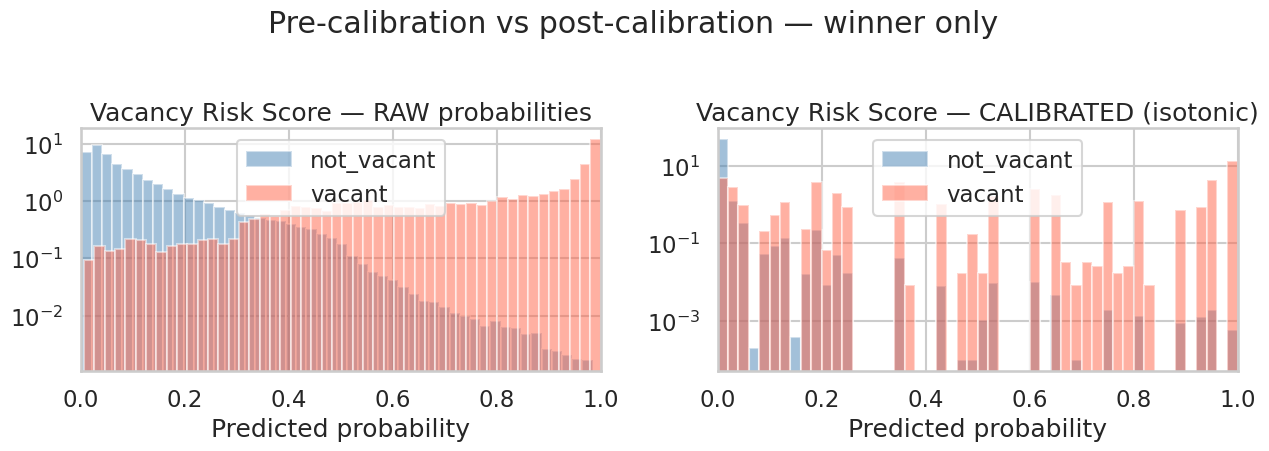

In [97]:
# Pre-cal vs post-cal probability distribution for the composite winner
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, probs, title in [
    (axes[0], raw_probs_best,   f'{best_model_name} — RAW probabilities'),
    (axes[1], all_probs_best,   f'{best_model_name} — CALIBRATED (isotonic)'),
]:
    ax.hist(probs[model_df['ovs'].values == 0], bins=50, alpha=0.5,
            label='not_vacant', color='steelblue', density=True)
    ax.hist(probs[model_df['ovs'].values == 1], bins=50, alpha=0.5,
            label='vacant', color='tomato', density=True)
    ax.set_xlim(0, 1)
    ax.set_yscale('log')
    ax.set_title(title)
    ax.set_xlabel('Predicted probability')
    ax.legend()
fig.suptitle('Pre-calibration vs post-calibration — winner only', y=1.02)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'cal_vs_raw_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


---
## 8. Export

Writes calibrated per-parcel predictions, per-model thresholds, and serialized
fitted models to `data_py/`.


In [98]:
# Attach quantile tier to the export so 04b/05 can use it directly
model_df_pred['qtile_tier'] = best_qtile

# all_predictions_rf.csv — every parcel, every model.
# PRODUCTION SCORE: ensemble_prob (calibrated) and risk_score (0–100 integer).
# Per-model columns retained for diagnostics & comparison; downstream code
# should default to ensemble_prob / risk_score / qtile_tier.
keep_cols = ['parcel_number', 'ovs', 'data_split',
             # production columns FIRST so downstream defaults grab them
             'ensemble_prob', 'risk_score', 'ensemble_prob_raw',
             'ensemble_flag', 'qtile_tier',
             # individual model probs (diagnostics)
             'rf_prob',     'logit_prob',     'xgb_prob',     'lgb_prob',
             'rf_prob_raw', 'logit_prob_raw', 'xgb_prob_raw', 'lgb_prob_raw',
             'rf_flag', 'logit_flag', 'xgb_flag', 'lgb_flag']
optional_cols = ['ovs_clean_seal', 'ovs_violation', 'ovs_license']
keep_cols = keep_cols[:3] + [c for c in optional_cols if c in model_df_pred.columns] + keep_cols[3:]

(model_df_pred[keep_cols]
   .assign(best_model=best_model_name)
   .to_csv(OUT_PATH / 'all_predictions_rf.csv', index=False))
print(f"Exported: all_predictions_rf.csv — {len(model_df_pred):,} rows")

# model_thresholds.csv — production model is 'ensemble' (Vacancy Risk Score)
thr_export = pd.DataFrame([
    {'model': 'rf',       **thresh_rf_cal,    'is_best': top_model_code == 'rf'},
    {'model': 'logit',    **thresh_logit_cal, 'is_best': top_model_code == 'logit'},
    {'model': 'xgb',      **thresh_xgb_cal,   'is_best': top_model_code == 'xgb'},
    {'model': 'lgb',      **thresh_lgb_cal,   'is_best': top_model_code == 'lgb'},
    {'model': 'ensemble', **thresh_ens_cal,   'is_best': top_model_code == 'ensemble'},
]).rename(columns={'sensitivity': 'sens', 'specificity': 'spec'})
thr_export.to_csv(OUT_PATH / 'model_thresholds.csv', index=False)
print(f"Exported: model_thresholds.csv — production model: {best_model_name}")

# Model artifacts
joblib.dump(final_rf_fit,  OUT_PATH / 'model_rf_final.joblib')
joblib.dump(final_xgb_fit, OUT_PATH / 'model_xgb_final.joblib')
joblib.dump(final_lgb_fit, OUT_PATH / 'model_lgb_final.joblib')
joblib.dump(logit_fit,     OUT_PATH / 'model_logit_final.joblib')
print('Exported: model_{rf,xgb,lgb,logit}_final.joblib')

# Calibrators (needed if you want to score new data without re-running 04a)
joblib.dump({'logit':    cal_logit_obj, 'rf':       cal_rf_obj,
             'xgb':      cal_xgb_obj,   'lgb':      cal_lgb_obj,
             'ensemble': cal_ens_obj},
            OUT_PATH / 'calibrators.joblib')
print('Exported: calibrators.joblib (includes ensemble calibrator)')


Exported: all_predictions_rf.csv — 520,196 rows
Exported: model_thresholds.csv — production model: Vacancy Risk Score
Exported: model_{rf,xgb,lgb,logit}_final.joblib
Exported: calibrators.joblib (includes ensemble calibrator)


### 8a. Write README for downstream consumers

A short reference for anyone reading these CSVs in 04b/05 or building the
dashboard. Regenerated each run so it stays in sync with the actual columns
and metrics.


In [99]:
readme_lines = []
A = readme_lines.append

A('# PhillyStat360 — `data_py/` outputs (Vacancy Risk Score)')
A('')
A(f'_Generated by `04a_tidymodeling.ipynb` on {dt.datetime.now():%Y-%m-%d}._')
A('')
A('## Production score')
A('')
A('The headline model is **Vacancy Risk Score** — a calibrated 50/50 ensemble')
A('of class-balanced Logistic Regression and Random Forest. Both contribute')
A('equally to the raw average; isotonic calibration is applied once at the end.')
A('')
A(f"- Test ROC-AUC: **{thresh_ens_cal['auc']:.4f}**")
A(f"- Test PR-AUC:  **{average_precision_score(y_test, ensemble_probs_calibrated):.4f}** "
  '(ensemble beats both parents)')
A(f"- Test Brier:   **{brier_score_loss(y_test, ensemble_probs_calibrated):.4f}**")
A('')
A('## Files')
A('')
A('| File | Purpose |')
A('|---|---|')
A('| `all_predictions_rf.csv` | One row per parcel × all model probabilities + flag |')
A('| `model_thresholds.csv` | Per-model Youden thresholds + AUC |')
A('| `model_*_final.joblib` | Pickled fitted models (logit, rf, xgb, lgb) |')
A('| `calibrators.joblib` | Per-model + ensemble isotonic calibrators |')
A('| `equity_zip_audit.csv` | ZIP-level flag rate, vacancy rate, precision |')
A('| `cache/04a/*.joblib` | Per-run prediction cache (safe to delete) |')
A('')
A('## Which column should I use? (THE IMPORTANT PART)')
A('')
A('`all_predictions_rf.csv` has many score columns. Use the right one for the job:')
A('')
A('| Column | What it is | Use for |')
A('|---|---|---|')
A('| `risk_score` | Ensemble probability × 100, integer 0–100 | **Dashboard display** ("Risk: 42") |')
A('| `ensemble_prob` | Calibrated ensemble probability, 0–1 | "X% chance of being vacant" callouts |')
A('| `ensemble_prob_raw` | Uncalibrated ensemble, 0–1 | **Ranking & sorting** — preserves spread |')
A('| `ensemble_flag` | 1 = top 1% by raw rank | **Operational triage** — "should we inspect?" |')
A('| `qtile_tier` | 5-band rank bucket | Tier badges in UI ("Top 1% (highest risk)") |')
A('| `*_prob`, `*_prob_raw`, `*_flag` (per model) | Diagnostic — single-model views | Debugging, audits |')
A('')
A('### Why the calibrated probabilities all look small')
A('')
A('Vacancy is rare (1.1% prevalence). Isotonic calibration maps raw scores back')
A('to honest empirical positive rates — even the "Top 1%" of parcels is only')
A('~59% truly vacant, so the highest calibrated probability is ~0.6, not 1.0.')
A('This is correct behavior. **Do NOT compare calibrated probabilities to a fixed')
A('threshold like 0.5** — almost nothing will exceed it. Use `ensemble_flag` (top')
A('1% by rank) or `qtile_tier` for any "is this parcel risky enough to act on?"')
A('decision.')
A('')
A('## Equity considerations (read this before shipping)')
A('')
A('The model concentrates flags in predominantly Black/Latino, low-income North')
A('Philadelphia ZIPs (19132, 19134, 19140, 19133, 19104). Some of this reflects')
A('genuinely higher vacancy in those neighborhoods — but the model **amplifies**')
A('the disparity: flag rate is ~5–10× the underlying vacancy rate in those ZIPs,')
A('versus close to 1× in lower-vacancy ZIPs.')
A('')
A('**Operational implications:**')
A('- Inspections will concentrate in a small number of neighborhoods. Brief the')
A('  oversight team before launch.')
A('- See `equity_zip_audit.csv` for per-ZIP flag rate vs observed vacancy rate.')
A('- Consider a "max flags per ZIP" cap or per-ZIP top-N selection if')
A('  geographic balance matters operationally.')
A('')
A('## Re-training and cache invalidation')
A('')
A('Cache files are fingerprinted with a SHA-1 of the feature list. Any change')
A(f'to `model_vars` (current hash: `{FEATURE_HASH}`) produces a new cache key,')
A('so stale fits are silently bypassed. To force a clean retrain, delete')
A('`data_py/cache/04a/`.')

(OUT_PATH / 'README.md').write_text('\n'.join(readme_lines), encoding='utf-8')
print(f"Exported: README.md ({len(readme_lines)} lines)")


Exported: README.md (69 lines)


---
## 9. Equity diagnostic — flag-rate by ZIP code

Vacancy prediction concentrating inspections in particular neighborhoods is a
real disparate-impact risk. This section reports flag rate (% parcels flagged
by ensemble) and observed precision (% of flagged parcels actually vacant) per
ZIP code. **Look for:**

- ZIP codes where flag rate is very high *and* precision is low → model is
  flagging a lot but those flags aren't panning out as actual vacancies. That's
  a directional bias signal.
- ZIP codes where flag rate is high *and* precision is high → model is correctly
  identifying high-vacancy areas. This is the model working as designed but is
  worth surfacing for transparency.
- Overall: the flag-rate distribution should not be wildly skewed toward a
  small number of ZIPs unless those ZIPs genuinely have higher vacancy.

The output is also written to `data_py/equity_zip_audit.csv` for follow-up.


In [100]:
if 'zip_code' not in model_df_pred.columns:
    print('zip_code not present — skipping equity audit.')
else:
    eq = (
        model_df_pred.dropna(subset=['zip_code'])
        .groupby('zip_code')
        .agg(n_parcels=('parcel_number', 'size'),
             n_flagged=('ensemble_flag', 'sum'),
             n_observed_vacant=('ovs',  lambda s: int((s == 1).sum())),
             mean_score=('risk_score', 'mean'))
        .reset_index()
    )
    eq['flag_rate']     = eq['n_flagged']         / eq['n_parcels']
    eq['vacancy_rate']  = eq['n_observed_vacant'] / eq['n_parcels']
    # Precision among flagged in this zip (NaN when n_flagged == 0)
    flagged_truth = (
        model_df_pred.dropna(subset=['zip_code'])
        .query('ensemble_flag == 1')
        .groupby('zip_code')['ovs']
        .agg(['size', 'sum'])
        .rename(columns={'size': 'n_flagged_check', 'sum': 'tp'})
    )
    eq = eq.merge(flagged_truth, left_on='zip_code', right_index=True, how='left')
    eq['precision_at_flag'] = (eq['tp'] / eq['n_flagged']).where(eq['n_flagged'] > 0)
    eq = eq.drop(columns=['n_flagged_check'])

    # Filter to ZIPs with enough mass to be meaningful (≥500 parcels — keeps
    # ~all Philly residential ZIPs, drops a few sliver ones)
    eq_meaningful = eq[eq['n_parcels'] >= 500].sort_values('flag_rate', ascending=False)
    eq_meaningful.to_csv(OUT_PATH / 'equity_zip_audit.csv', index=False)

    print(f"Equity audit covers {len(eq_meaningful)} ZIPs (≥500 parcels each)")
    print(f"  Median flag rate across ZIPs:  {eq_meaningful['flag_rate'].median():.1%}")
    print(f"  Max flag rate (single ZIP):    {eq_meaningful['flag_rate'].max():.1%}")
    print(f"  Min flag rate (single ZIP):    {eq_meaningful['flag_rate'].min():.1%}")
    print(f"  Median precision-at-flag:      "
          f"{eq_meaningful['precision_at_flag'].median():.1%}")
    print(f"\nTop 10 ZIPs by flag rate:")
    display_cols = ['zip_code', 'n_parcels', 'flag_rate',
                    'vacancy_rate', 'precision_at_flag']
    display_eq = eq_meaningful.head(10)[display_cols].copy()
    for c in ['flag_rate', 'vacancy_rate', 'precision_at_flag']:
        display_eq[c] = display_eq[c].map(lambda v: '—' if pd.isna(v) else f'{v:.1%}')
    print(display_eq.to_string(index=False))


Equity audit covers 46 ZIPs (≥500 parcels each)
  Median flag rate across ZIPs:  0.5%
  Max flag rate (single ZIP):    2.9%
  Min flag rate (single ZIP):    0.0%
  Median precision-at-flag:      79.3%

Top 10 ZIPs by flag rate:
 zip_code  n_parcels flag_rate vacancy_rate precision_at_flag
  19139.0      14713      2.9%         2.8%             73.4%
  19121.0      11867      2.8%         2.9%             77.0%
  19140.0      18805      2.7%         2.6%             72.7%
  19134.0      21910      2.5%         2.6%             77.4%
  19132.0      15581      2.5%         3.8%            100.0%
  19104.0       8783      2.5%         2.5%             72.1%
  19142.0      10243      2.2%         2.1%             71.6%
  19143.0      23461      2.1%         2.2%             76.4%
  19144.0      11504      2.0%         2.0%             69.8%
  19133.0       8838      1.9%         2.0%             72.9%


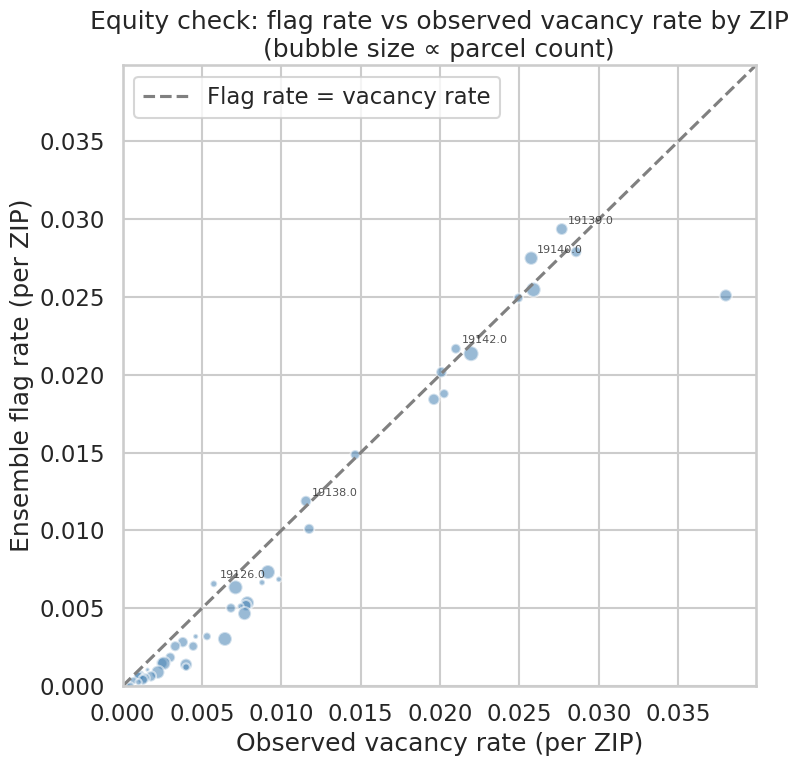

In [101]:
# Visual: flag rate vs observed vacancy rate per ZIP. A model that is
# "fair on its own terms" sits along the y=x line — flag rate tracks the
# underlying vacancy rate. Big positive deviations (above line) = over-flagging,
# big negative = under-flagging.
if 'zip_code' in model_df_pred.columns and len(eq_meaningful) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(eq_meaningful['vacancy_rate'], eq_meaningful['flag_rate'],
               s=eq_meaningful['n_parcels'] / 200, alpha=0.55, color='steelblue',
               edgecolors='white')
    lim = max(eq_meaningful['vacancy_rate'].max(),
              eq_meaningful['flag_rate'].max()) * 1.05
    ax.plot([0, lim], [0, lim], '--', color='gray', label='Flag rate = vacancy rate')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Observed vacancy rate (per ZIP)')
    ax.set_ylabel('Ensemble flag rate (per ZIP)')
    ax.set_title('Equity check: flag rate vs observed vacancy rate by ZIP\n'
                 '(bubble size ∝ parcel count)')
    ax.legend()

    # Annotate top 5 over-flaggers
    eq_meaningful = eq_meaningful.assign(
        diff=lambda d: d['flag_rate'] - d['vacancy_rate'])
    top5 = eq_meaningful.nlargest(5, 'diff')
    for _, row in top5.iterrows():
        ax.annotate(str(row['zip_code']),
                    (row['vacancy_rate'], row['flag_rate']),
                    fontsize=8, alpha=0.8,
                    xytext=(4, 4), textcoords='offset points')
    plt.tight_layout()
    plt.savefig(GRAPH_PATH / 'equity_zip_scatter.png', dpi=200, bbox_inches='tight')
    plt.show()


---
**Done.** Outputs in `PhillyStat360/data_py/`. Production score column for the
dashboard is `risk_score` (0–100 integer); for ranking & quantile cuts use
`ensemble_prob_raw` or `qtile_tier`. Equity audit at
`data_py/equity_zip_audit.csv`. To re-train from scratch, delete
`data_py/cache/04a/` before re-running.


In [102]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04a_tidymodeling.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04a_tidymodeling.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1754039 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04a_tidymodeling.html
